# Electricity model — monthly BVAR-SV-outlier with seasonal dummies

This notebook estimates the electricity component of the energy-inflation suite. The endogenous block contains monthly absolute changes in wholesale natural-gas prices and pre-tax consumer electricity prices. Eleven calendar-month dummies enter as deterministic regressors; January is the omitted reference month because the model also contains a constant.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]
for candidate in MODEL_DIR_CANDIDATES:
    required_modules = (
        "energy_bvar_model.py",
        "energy_bvar_electricity.py",
        "energy_bvar_plot.py",
        "energy_bvar_io.py",
    )
    if all((candidate / name).exists() for name in required_modules):
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Place energy_bvar_model.py, energy_bvar_electricity.py, "
        "energy_bvar_plot.py and energy_bvar_io.py beside this notebook "
        "or in src/model/."
    )

from energy_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    coefficient_posterior_tables,
    forecast_bvar_sv_outlier,
    forecast_error_variance_decomposition,
    forecast_horizon_table,
    historical_decomposition,
    impulse_responses,
    make_bvar_svo_prior,
    mcmc_diagnostics,
    nowcast_summary_table,
    path_horizon_table,
    posterior_outlier_probability,
    posterior_predictive_statistics,
    prepare_bvar_panel,
    residual_diagnostic_table,
    run_energy_bvar,
    stability_diagnostics,
    stationarity_tests,
)
from energy_bvar_io import save_energy_bvar_result
from energy_bvar_electricity import (
    electricity_series_construction_table,
    forecast_to_hicp_electricity,
    load_electricity_panel,
    load_electricity_tax_context,
    make_electricity_seasonal_dummies,
    validate_electricity_tax_round_trip,
)
from energy_bvar_plot import (
    format_number,
    plot_absolute_differences,
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_data_levels,
    plot_fevd,
    plot_forecast_comparison,
    plot_hicp_forecast_fan,
    plot_historical_decomposition,
    plot_impulse_responses,
    plot_minnesota_prior_by_equation,
    plot_nowcast_fan,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_short_forecast_fan,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    plot_volatility_decomposition,
    style_numeric_table,
)

pd.set_option("display.max_rows", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

SEED = 42
P = 12
REFERENCE_MONTH = 1
EXOG_PRIOR_SCALE = 10.0
VARIABLES = ["natural_gas_wholesale", "electricity_pre_tax"]
UNITS = {
    "natural_gas_wholesale": "EUR/MWh",
    "electricity_pre_tax": "EUR/kWh",
}
SAVE_RESULTS = False
RESULTS_ROOT = PROJECT_ROOT / "results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model modules: {MODEL_DIR}")

Project root: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Model modules: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model


## 2. Data and deterministic regressors

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260805\electricity_monthly.csv
Sample calendar: 2003-07-01 to 2026-08-01
Seasonal reference month: 01


,series_type,model_unit,source_inputs,construction,note
natural_gas_wholesale,chain-linked wholesale price,EUR/MWh,"Bloomberg TTF; World Bank Natural gas, Europe; EUR/USD","Bloomberg TTF monthly mean; earlier months backcast with the World Bank Natural gas, Europe proxy via backward chain-linking. The proxy level is pinned to TTF at the anchor month; no overlap window and no level regression are estimated.",Wholesale natural gas is the upstream explanatory variable.
electricity_pre_tax,constructed pre-tax price,EUR/kWh,"Haver HICP electricity; Eurostat after-tax price, VAT and excise",pre_tax_EUR_MWh = gamma_EUR_MWh * HICP / (1 + VAT/100) - EXC_EUR_MWh,"After the final published six-month semester, VAT and excise are held constant through the last available monthly HICP observation, matching the paper's unchanged-tax assumption. Estimated gamma: 0.00321719."


,natural_gas_wholesale,electricity_pre_tax
date,,
2025-09-01,32.02,0.23
2025-10-01,32.04,0.23
2025-11-01,30.66,0.23
2025-12-01,27.42,0.23
2026-01-01,34.52,0.23
2026-02-01,32.51,0.23
2026-03-01,52.63,0.23
2026-04-01,45.26,0.23
2026-05-01,47.34,0.23


,month_02,month_03,month_04,month_05,month_06,month_07,month_08,month_09,month_10,month_11,month_12
date,,,,,,,,,,,
2025-09-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2025-10-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
2025-11-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
2025-12-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2026-01-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-02-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-03-01,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-04-01,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-05-01,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


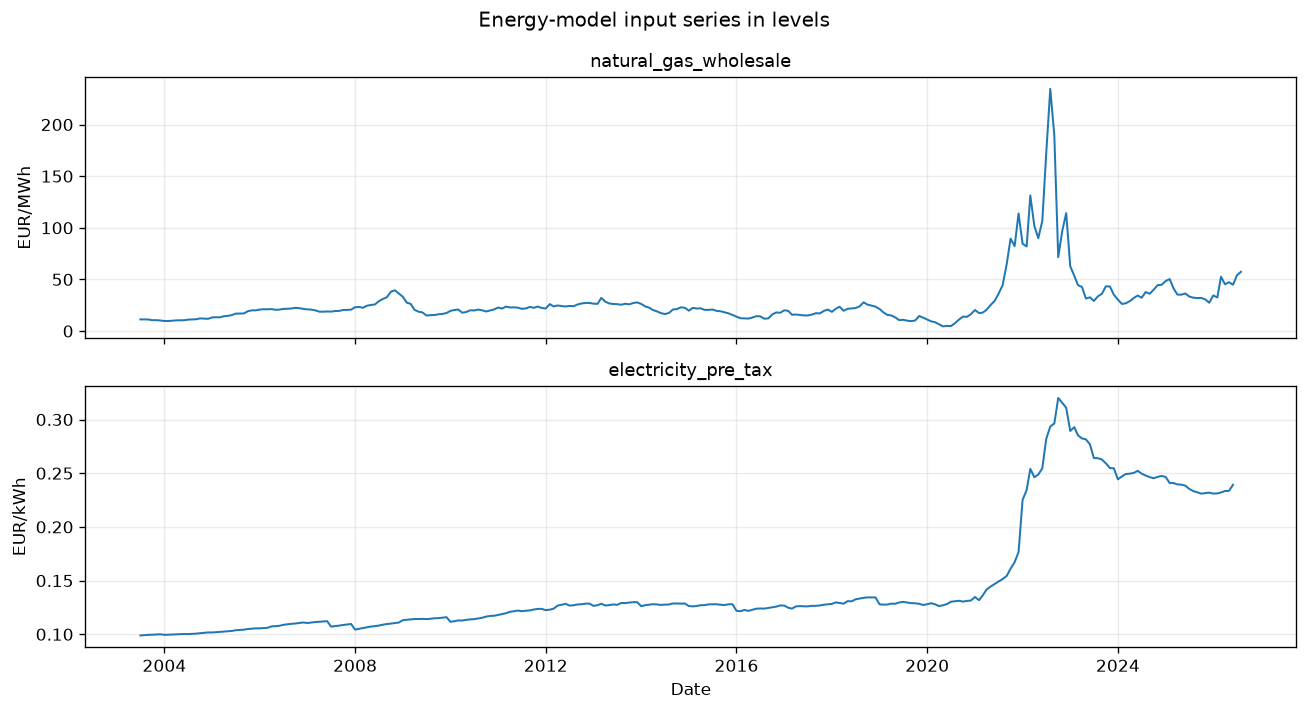

In [2]:
# Set VINTAGE = "YYYYMMDD" to force one processed vintage.
VINTAGE = None
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

if VINTAGE is None:
    candidates = sorted(
        path for path in PROCESSED_ROOT.glob("*/electricity_monthly.csv")
        if path.is_file()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No electricity_monthly.csv found below {PROCESSED_ROOT}."
        )
    ELECTRICITY_DATASET = candidates[-1]
else:
    ELECTRICITY_DATASET = PROCESSED_ROOT / VINTAGE / "electricity_monthly.csv"

levels = load_electricity_panel(ELECTRICITY_DATASET, variables=VARIABLES)
seasonal_dummies = make_electricity_seasonal_dummies(
    levels.index,
    reference_month=REFERENCE_MONTH,
)

print(f"Dataset: {ELECTRICITY_DATASET}")
print(f"Sample calendar: {levels.index.min().date()} to {levels.index.max().date()}")
print(f"Seasonal reference month: {REFERENCE_MONTH:02d}")

display(style_numeric_table(
    electricity_series_construction_table(ELECTRICITY_DATASET),
    caption="Construction of the electricity-model level series",
))
display(style_numeric_table(
    levels.tail(12),
    caption="Latest processed levels",
))
display(style_numeric_table(
    seasonal_dummies.tail(12),
    caption="Known calendar-month deterministic regressors",
))
plot_data_levels(levels, units=UNITS)
plt.show()

### Absolute monthly changes

The endogenous vector is

$$
y_t =
\begin{bmatrix}
\Delta P_t^{\mathrm{gas}} \\
\Delta P_t^{\mathrm{electricity,pre-tax}}
\end{bmatrix},
\qquad
\Delta P_t=P_t-P_{t-1}.
$$

Seasonal dummies are **not differenced**. They are deterministic indicators attached to the current calendar month.

,value
balanced_change_start,2003-08-01 00:00:00
balanced_change_end,2026-06-01 00:00:00
balanced_changes,275
VAR_regression_observations,263
seasonal_regressors,11
regression_columns_per_equation,36
ragged_edge_months,2
latest_calendar_month,2026-08-01 00:00:00


,natural_gas_wholesale,electricity_pre_tax
date,,
2026-07-01,9.11,—
2026-08-01,3.43,—


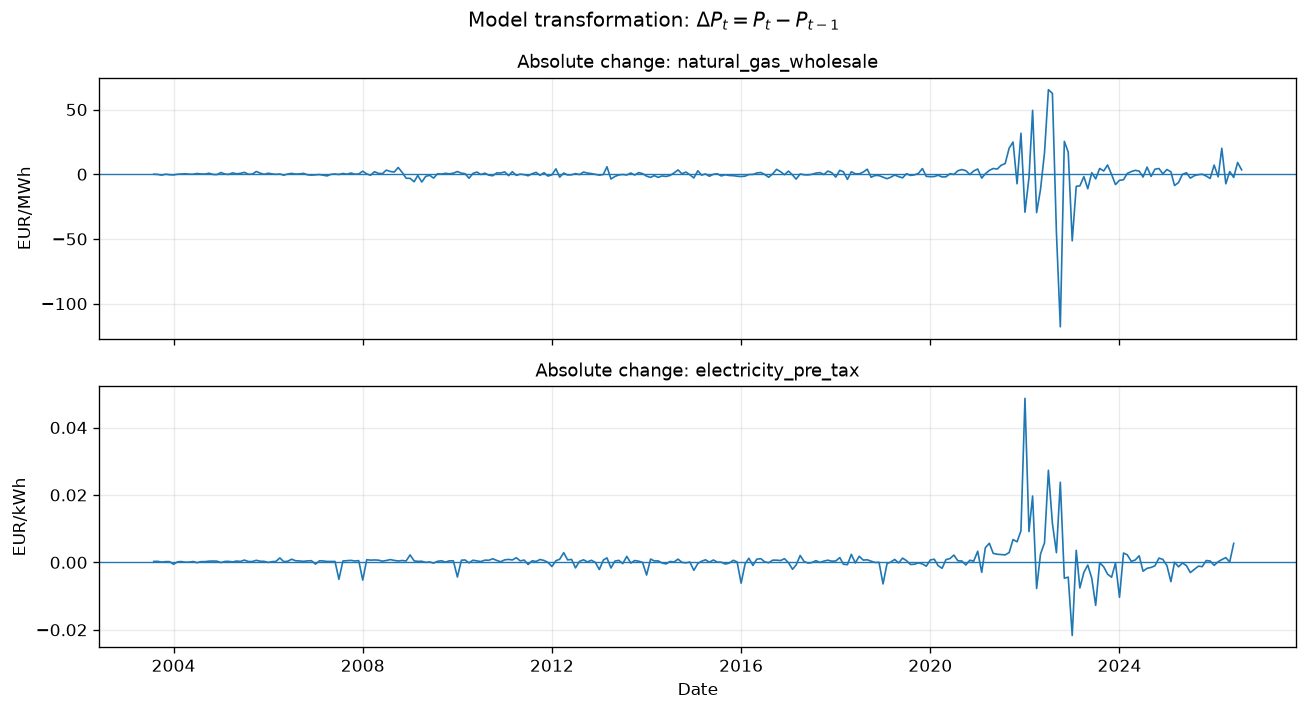

In [3]:
prep = prepare_bvar_panel(
    levels,
    p=P,
    variables=VARIABLES,
    exog=seasonal_dummies,
)

transformation_summary = pd.Series({
    "balanced_change_start": prep["balanced_start"],
    "balanced_change_end": prep["balanced_end"],
    "balanced_changes": prep["n_balanced_changes"],
    "VAR_regression_observations": prep["n_regression_observations"],
    "seasonal_regressors": prep["n_exog"],
    "regression_columns_per_equation": prep["k"],
    "ragged_edge_months": prep["n_ragged_months"],
    "latest_calendar_month": prep["last_calendar_date"],
})
display(style_numeric_table(
    transformation_summary.to_frame("value"),
    caption="Transformation, deterministic block and sample",
))
display(style_numeric_table(
    prep["ragged"],
    caption="Ragged-edge absolute changes",
))
plot_absolute_differences(prep["differences"], units=UNITS)
plt.show()

## 3. Model

For $t=1,\ldots,T$, the model is

$$
y_t = c + \sum_{\ell=1}^{12} B_\ell y_{t-\ell} + D s_t + \nu_t,
$$

where $s_t$ contains eleven monthly dummies. With January omitted, the constant is the January deterministic baseline and each coefficient in $D$ measures the difference relative to January.

The residual covariance follows

$$
\nu_t=A^{-1}O_t\Lambda_t^{1/2}\varepsilon_t,
\qquad \varepsilon_t\sim\mathcal N(0,I),
$$

with random-walk log volatilities and model-based transitory outlier scales.

## 4. Priors

,value,interpretation
lambda1,0.20,overall Minnesota lag tightness
lambda2,0.50,additional cross-lag tightness
lambda3,1.00,lag-decay exponent
lambda4,10.00,constant prior scale
exog_prior_scale,10.00,seasonal coefficient prior scale
A prior variance,10.00,variance of the free contemporaneous A coefficient
phi prior mean,0.02,prior mean of volatility-of-volatility variance
outlier alpha,2.50,Beta outlier pseudo-count
outlier beta,117.50,Beta regular-observation pseudo-count


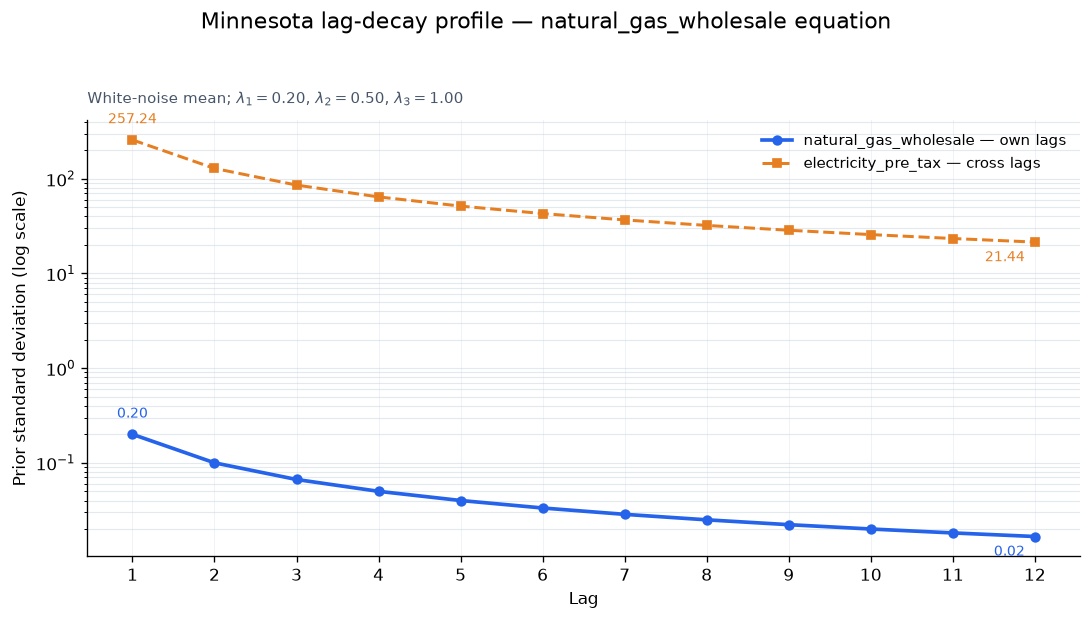

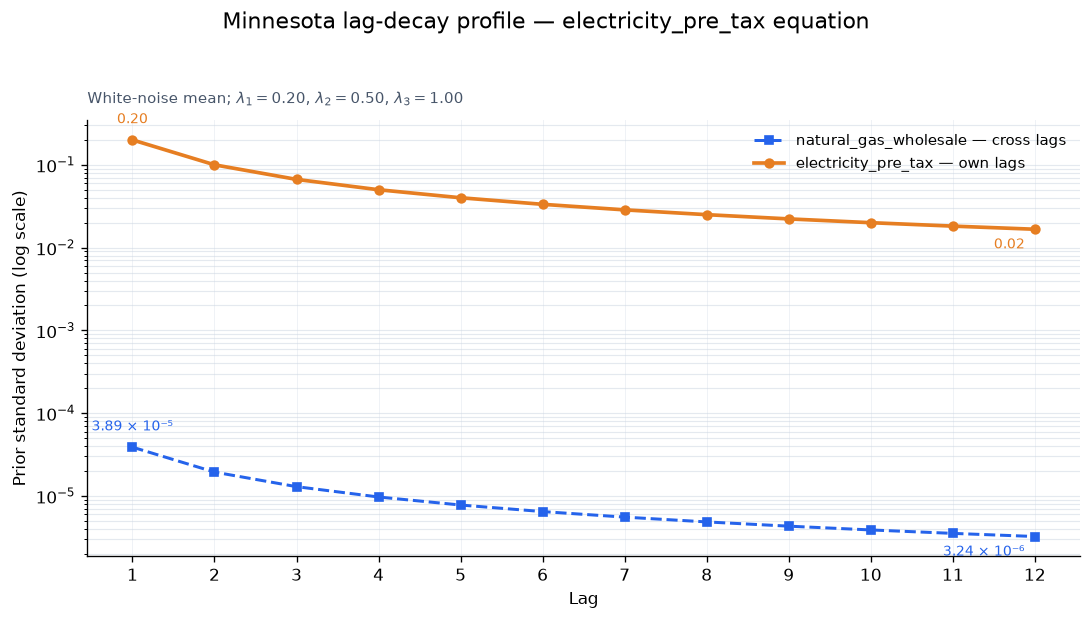

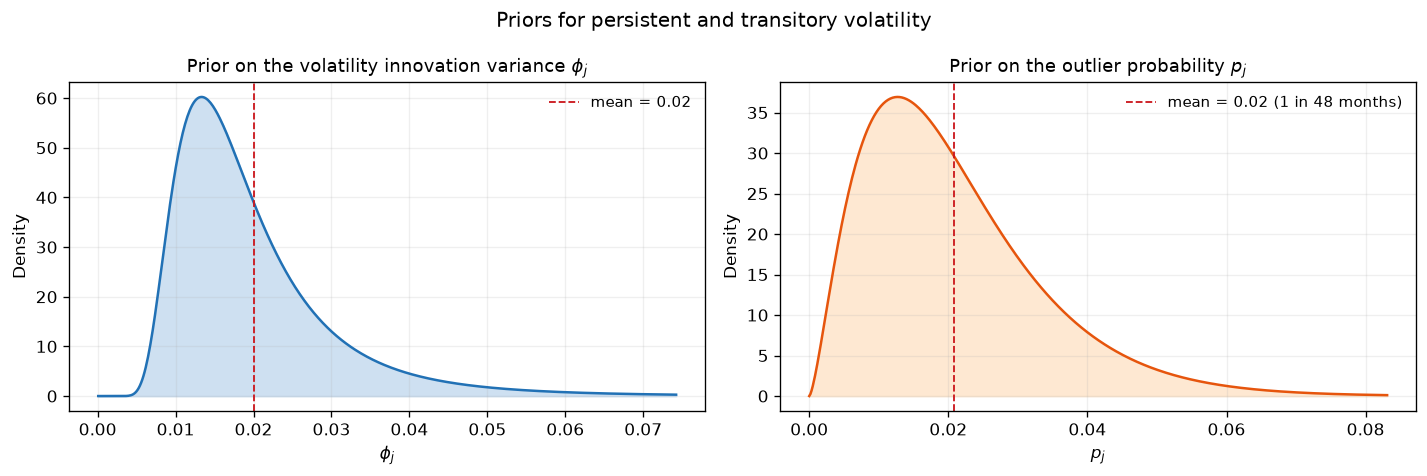

In [4]:
prior_config = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
prior = make_bvar_svo_prior(
    prep,
    prior_config,
    exog_prior_scale=EXOG_PRIOR_SCALE,
)

prior_table = pd.DataFrame({
    "value": [
        prior_config.lambda1,
        prior_config.lambda2,
        prior_config.lambda3,
        prior_config.lambda4,
        EXOG_PRIOR_SCALE,
        prior_config.a_prior_var,
        prior_config.phi_prior_mean,
        prior["outlier_alpha"],
        prior["outlier_beta"],
    ],
    "interpretation": [
        "overall Minnesota lag tightness",
        "additional cross-lag tightness",
        "lag-decay exponent",
        "constant prior scale",
        "seasonal coefficient prior scale",
        "variance of the free contemporaneous A coefficient",
        "prior mean of volatility-of-volatility variance",
        "Beta outlier pseudo-count",
        "Beta regular-observation pseudo-count",
    ],
}, index=[
    "lambda1", "lambda2", "lambda3", "lambda4",
    "exog_prior_scale", "A prior variance", "phi prior mean",
    "outlier alpha", "outlier beta",
])
display(style_numeric_table(prior_table, caption="Prior hyperparameters"))

prior_figures = plot_minnesota_prior_by_equation(prior, VARIABLES, P)
for equation, figure in prior_figures.items():
    display(figure)
    plt.close(figure)
plot_phi_and_outlier_priors(prior)
plt.show()

## 5. Posterior and Gibbs sampler

The coefficient draw treats the constant, lag coefficients and seasonal coefficients as one Gaussian regression block. Stability truncation applies only to the autoregressive lag block; deterministic coefficients do not enter the companion roots. The SV block jointly updates the complete volatility path and its innovation variance using the centered KSC sampler.

In [5]:
sampler_config = SamplerConfig(
    reps=6_000,
    burn=3_000,
    thin=1,
    seed=SEED,
    max_stability_tries=1_000,
    progress_every=500,
)

result = run_energy_bvar(
    levels=levels,
    model_id="electricity",
    vintage=ELECTRICITY_DATASET.parent.name,
    p=P,
    variables=VARIABLES,
    exog=seasonal_dummies,
    exog_prior_scale=EXOG_PRIOR_SCALE,
    prior_config=prior_config,
    sampler_config=sampler_config,
    code_version="energy_bvar_model-exog-v1",
)

print(f"Retained posterior draws: {result['n_draws']:,}")
print(f"Run ID: {result['metadata']['run_id']}")
print(f"B instability proposal rejection rate: {result['B_instability_rejection_rate']:.2%}")
print(f"Deterministic regressors: {result['exog_names']}")
display(style_numeric_table(
    pd.Series(dict(zip(VARIABLES, result["ksc_offsets"]))).to_frame("KSC offset"),
    caption="Adaptive KSC offsets",
))

if SAVE_RESULTS:
    saved_result_paths = save_energy_bvar_result(result, RESULTS_ROOT)
    print(f"Saved run: {saved_result_paths['directory']}")

iteration 500/6,000 | B instability rejection 0.00% | radius 0.7707
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8211
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.7713
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.8000
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.7901
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.8028
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.7902
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8262
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.7470
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.7991
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.7667
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.7573
Retained posterior draws: 3,000
Run ID: 73b132b0c63213da0163ec29b182a1c844385ca687708a8aaa41dba666395817
B instability proposal rejection rate: 0.00%
Deterministi

,KSC offset
natural_gas_wholesale,6.68 × 10⁻⁶
electricity_pre_tax,1.43 × 10⁻¹²


## 6. Results

### 6.1 Posterior coefficients, including seasonal effects


natural_gas_wholesale equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,115.39,0.08,0.08,0.38,-0.55,-0.31,0.47,0.69,380.07
natural_gas_wholesale L1,0.00,0.20,0.07,0.07,0.07,-0.05,-2.86 × 10⁻³,0.14,0.18,477.64
electricity_pre_tax L1,0.00,257.24,131.88,130.90,93.55,-16.78,40.27,225.42,290.34,609.96
natural_gas_wholesale L2,0.00,0.10,0.03,0.03,0.06,-0.06,-0.03,0.09,0.12,1069.68
electricity_pre_tax L2,0.00,128.62,47.39,49.10,72.19,-71.45,-25.57,119.17,161.60,1841.52
natural_gas_wholesale L3,0.00,0.07,0.08,0.08,0.05,2.41 × 10⁻³,0.03,0.13,0.16,410.19
electricity_pre_tax L3,0.00,85.75,-15.98,-14.91,61.92,-117.67,-78.13,44.70,84.57,1697.89
natural_gas_wholesale L4,0.00,0.05,2.98 × 10⁻³,3.72 × 10⁻³,0.04,-0.06,-0.04,0.04,0.07,1816.17
electricity_pre_tax L4,0.00,64.31,8.19,9.45,52.73,-77.57,-44.35,60.64,93.24,1565.78


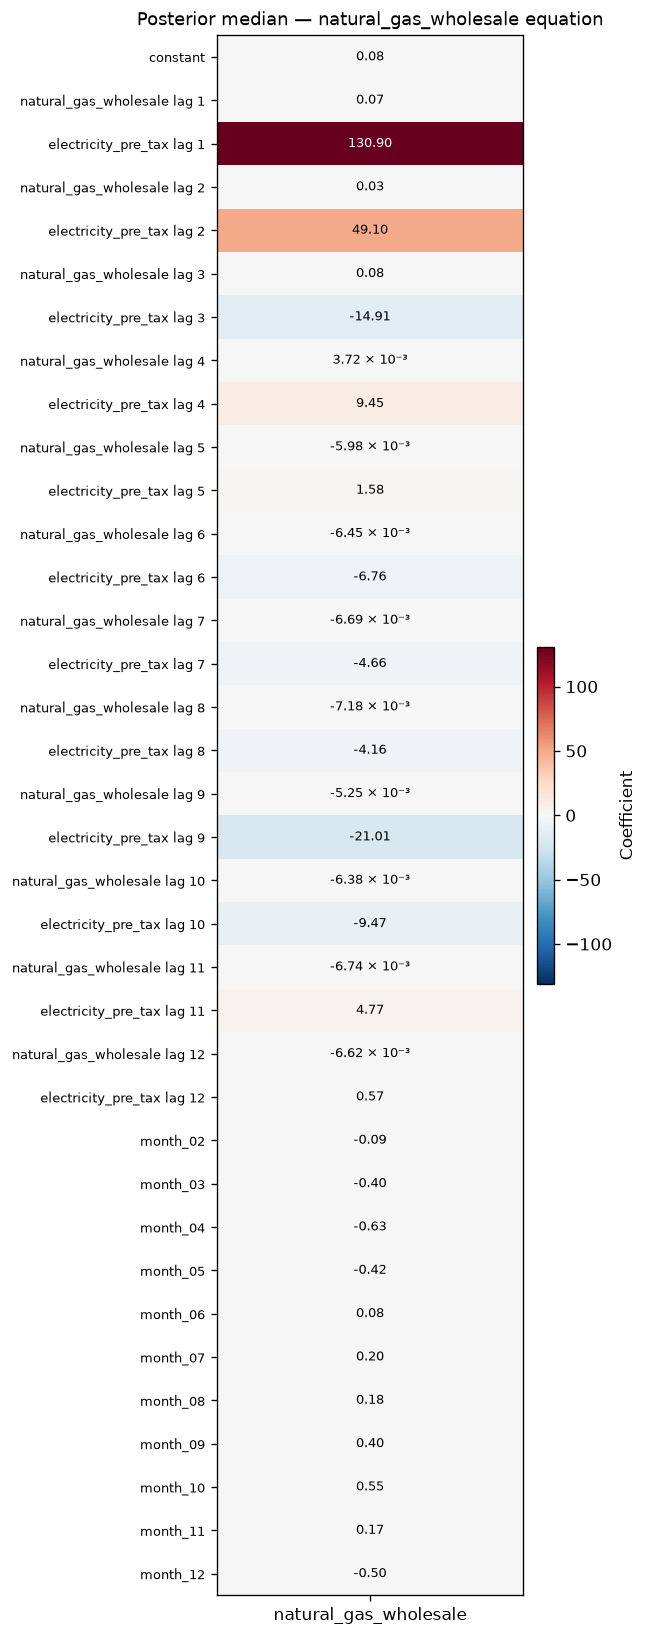

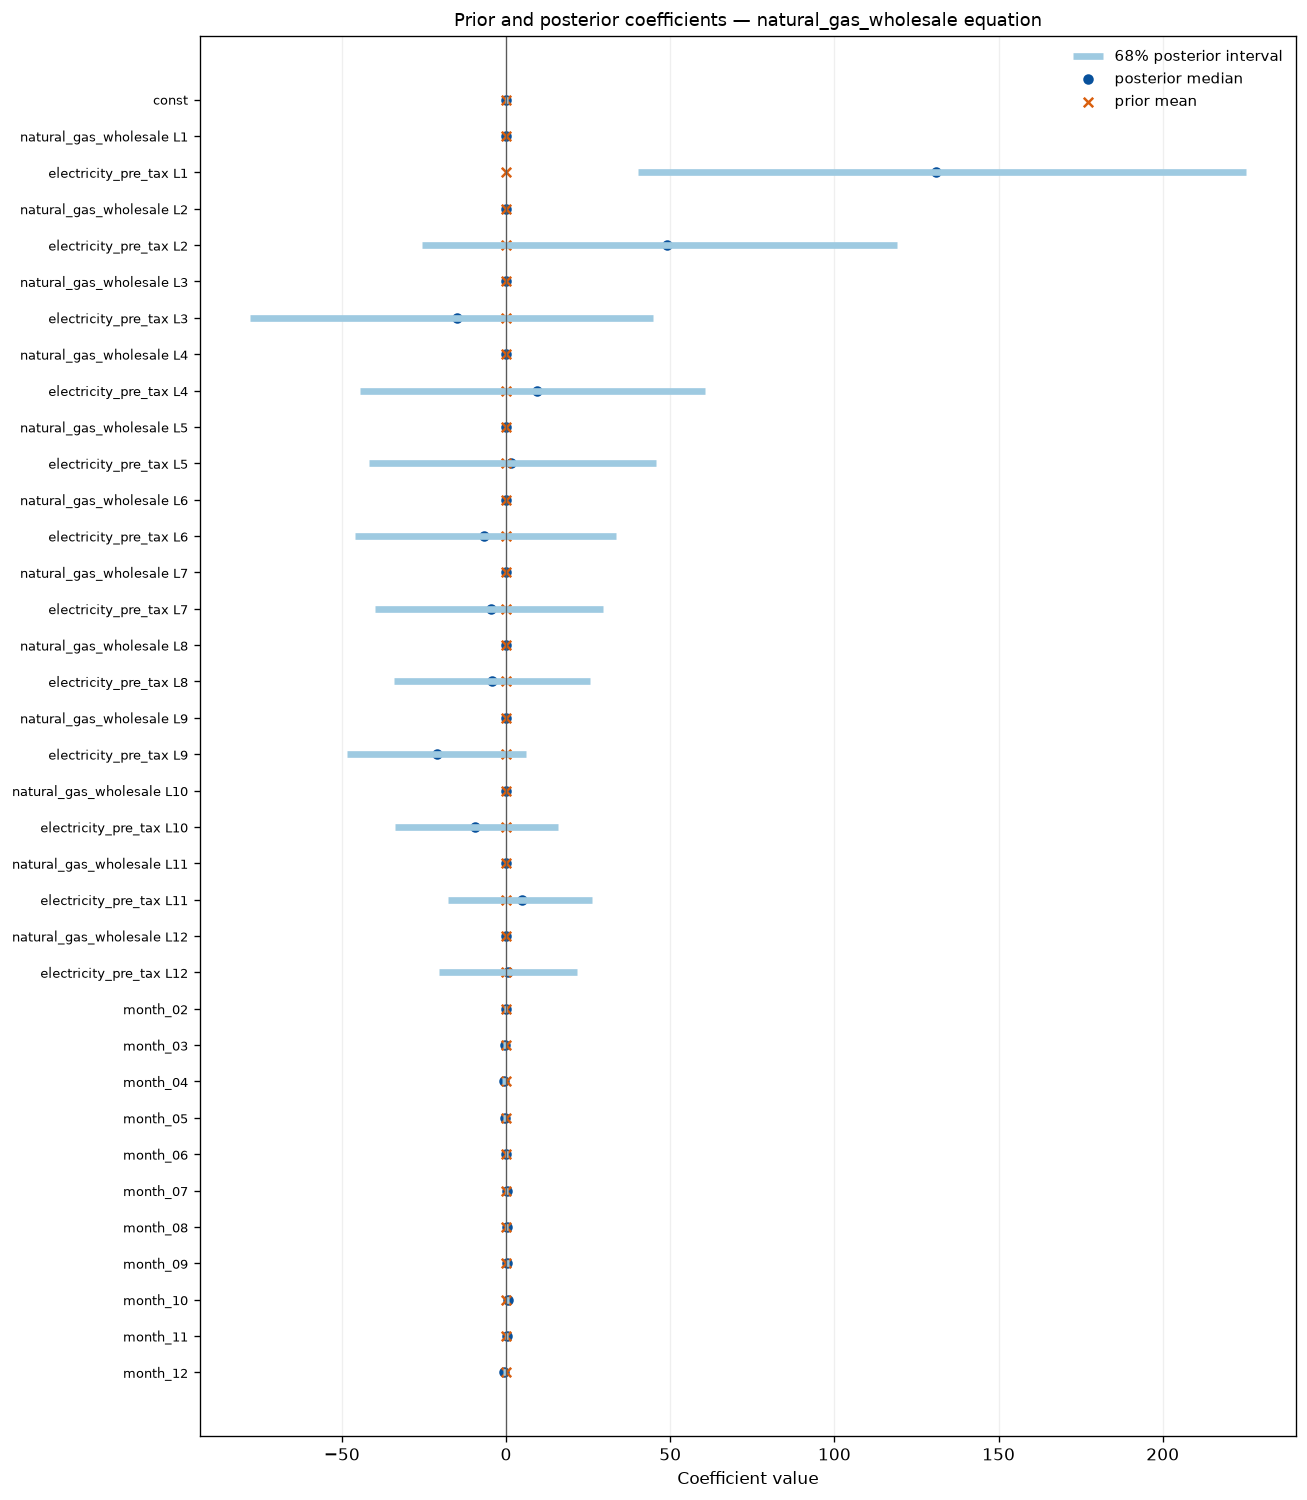


electricity_pre_tax equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,0.04,-3.23 × 10⁻⁴,-3.13 × 10⁻⁴,1.39 × 10⁻⁴,-5.71 × 10⁻⁴,-4.56 × 10⁻⁴,-1.89 × 10⁻⁴,-1.10 × 10⁻⁴,448.24
natural_gas_wholesale L1,0.00,3.89 × 10⁻⁵,5.80 × 10⁻⁶,6.46 × 10⁻⁶,1.94 × 10⁻⁵,-2.77 × 10⁻⁵,-1.38 × 10⁻⁵,2.54 × 10⁻⁵,3.66 × 10⁻⁵,187.41
electricity_pre_tax L1,0.00,0.20,0.03,0.03,0.03,-0.02,-2.29 × 10⁻³,0.06,0.08,634.33
natural_gas_wholesale L2,0.00,1.94 × 10⁻⁵,1.41 × 10⁻⁵,1.38 × 10⁻⁵,1.49 × 10⁻⁵,-9.67 × 10⁻⁶,-4.97 × 10⁻⁷,2.93 × 10⁻⁵,3.93 × 10⁻⁵,301.69
electricity_pre_tax L2,0.00,0.10,-0.01,-0.02,0.03,-0.06,-0.04,0.01,0.03,1446.45
natural_gas_wholesale L3,0.00,1.30 × 10⁻⁵,1.94 × 10⁻⁵,1.96 × 10⁻⁵,1.15 × 10⁻⁵,-6.81 × 10⁻⁸,8.00 × 10⁻⁶,3.10 × 10⁻⁵,3.84 × 10⁻⁵,1176.13
electricity_pre_tax L3,0.00,0.07,0.04,0.04,0.04,-0.01,6.07 × 10⁻³,0.08,0.10,319.34
natural_gas_wholesale L4,0.00,9.72 × 10⁻⁶,-1.09 × 10⁻⁶,-1.12 × 10⁻⁶,8.93 × 10⁻⁶,-1.59 × 10⁻⁵,-9.91 × 10⁻⁶,7.73 × 10⁻⁶,1.37 × 10⁻⁵,736.50
electricity_pre_tax L4,0.00,0.05,-7.30 × 10⁻³,-7.21 × 10⁻³,0.02,-0.05,-0.03,0.02,0.03,2552.09


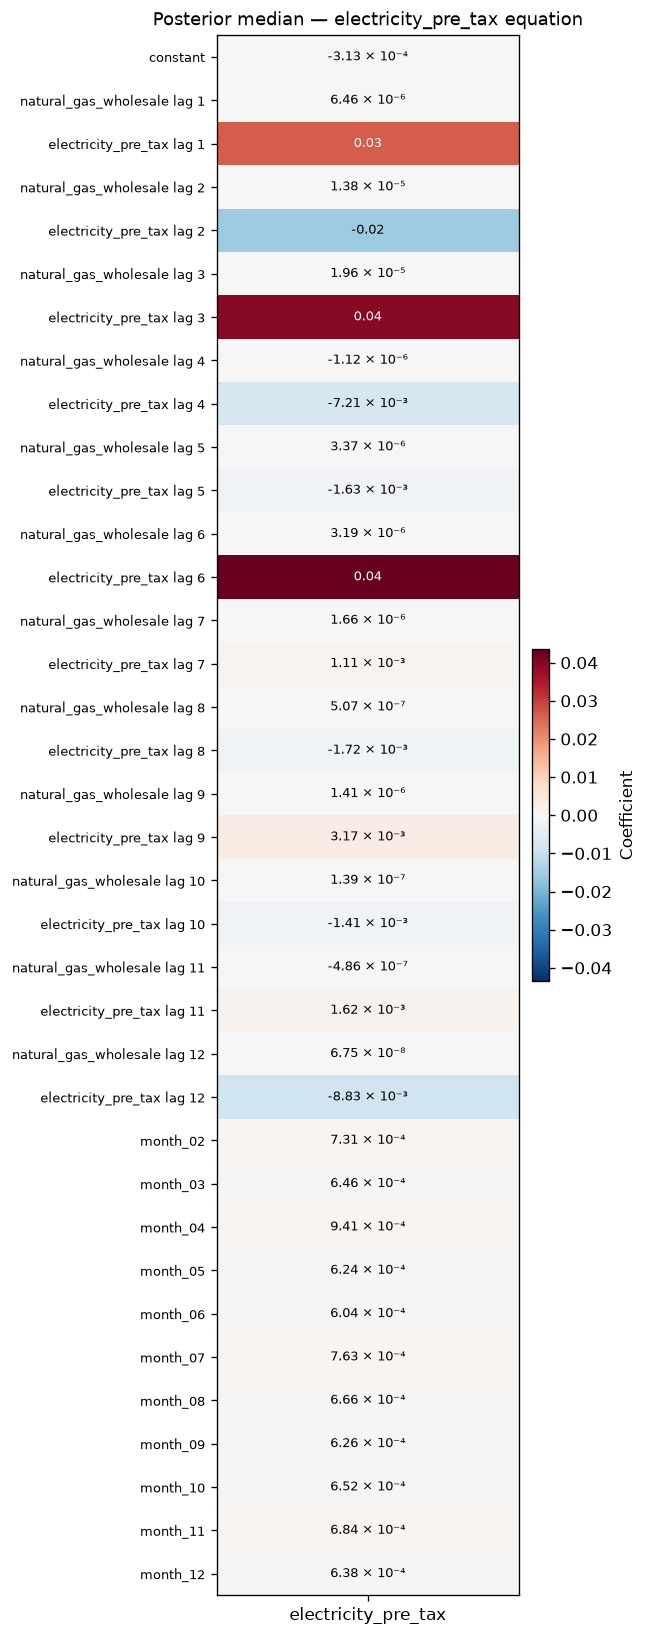

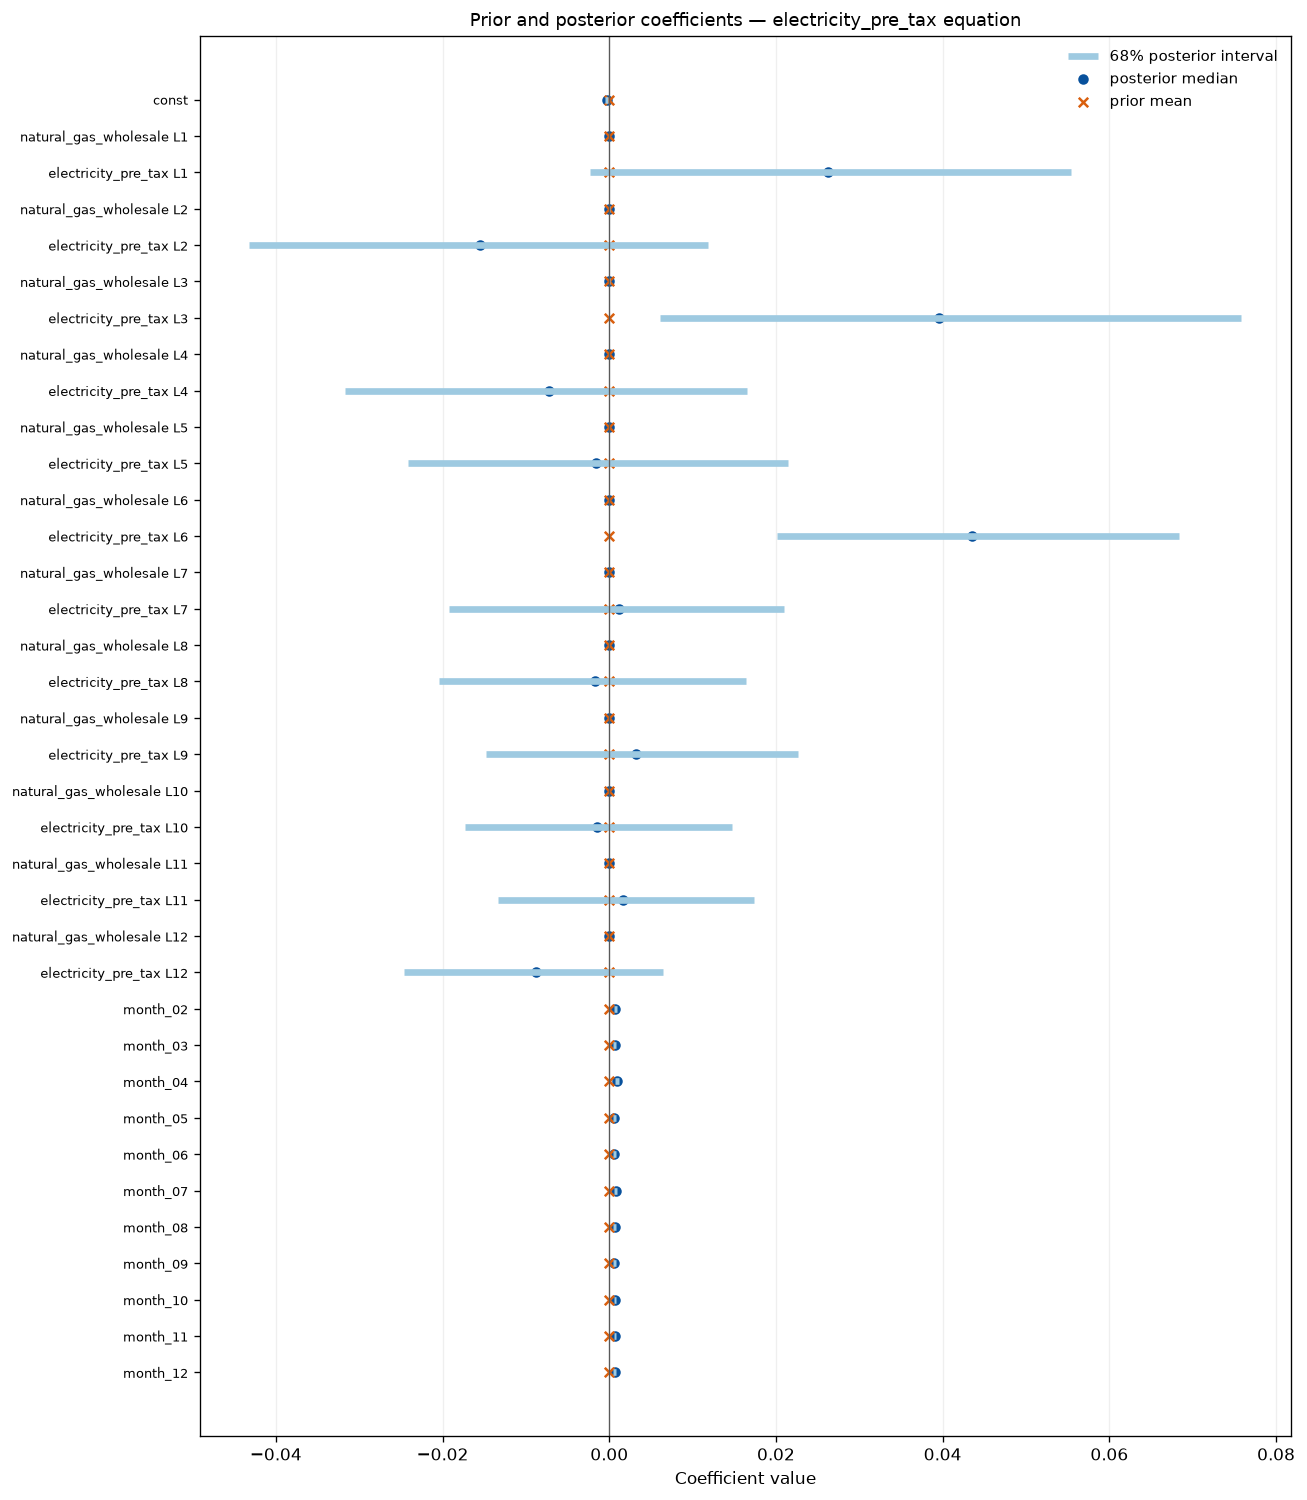

In [6]:
coefficient_tables = coefficient_posterior_tables(result)
for equation in VARIABLES:
    print(f"\n{equation} equation")
    display(style_numeric_table(
        coefficient_tables[equation],
        caption=f"Posterior coefficients — {equation} equation",
    ))
    plot_coefficient_heatmap(result, equation=equation)
    plot_shrinkage_comparison(result, equations=[equation])
    plt.show()

### 6.2 Stochastic volatility and transitory outliers

,,posterior_probability
date,,
2007-07-01,electricity_pre_tax,1.00
2008-01-01,electricity_pre_tax,1.00
2010-01-01,electricity_pre_tax,1.00
2016-01-01,electricity_pre_tax,1.00
2022-01-01,electricity_pre_tax,1.00
2019-01-01,electricity_pre_tax,1.00
2009-01-01,electricity_pre_tax,1.00
2014-01-01,electricity_pre_tax,0.89
2022-10-01,electricity_pre_tax,0.70


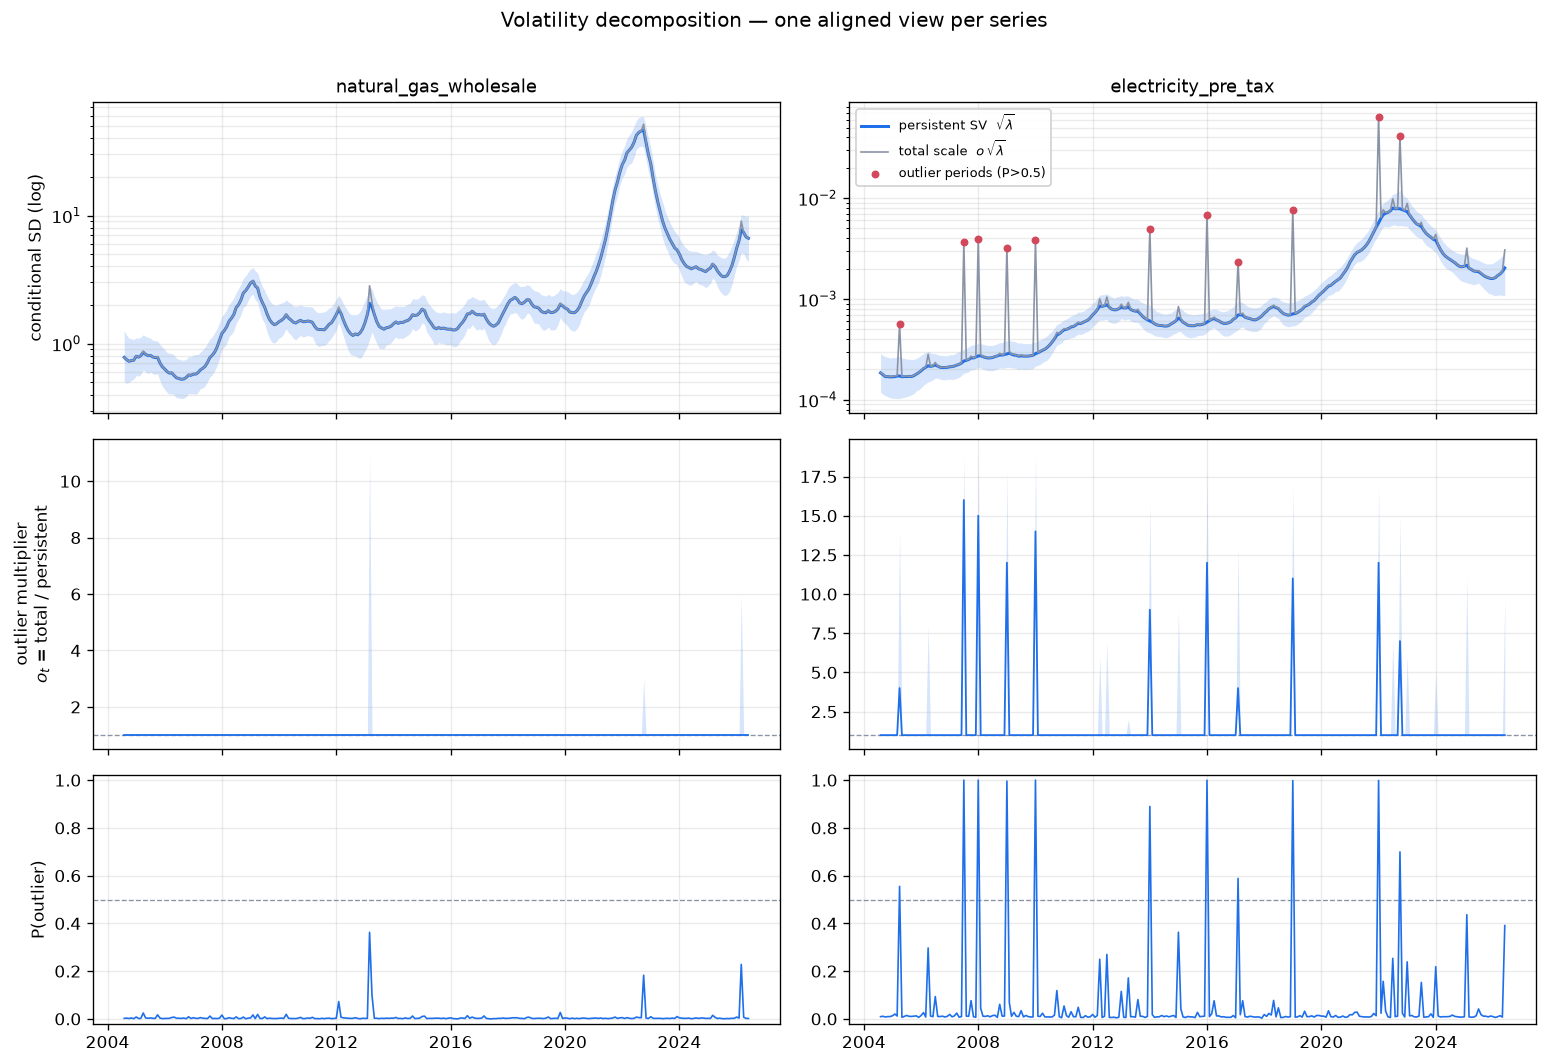

In [7]:
outlier_probability = posterior_outlier_probability(result)
important_outliers = (
    outlier_probability.stack()
    .rename("posterior_probability")
    .loc[lambda series: series >= 0.50]
    .sort_values(ascending=False)
    .to_frame()
)
display(style_numeric_table(
    important_outliers.head(30),
    caption="Dates with posterior outlier probability at least 50%",
))
plot_volatility_decomposition(result)
plt.show()

### 6.3 Standardized structural residuals

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
natural_gas_wholesale,0.01,0.93,0.12,-0.13,8.21 × 10⁻³,3.00
electricity_pre_tax,-0.04,0.96,2.03 × 10⁻³,0.48,0.04,2.92


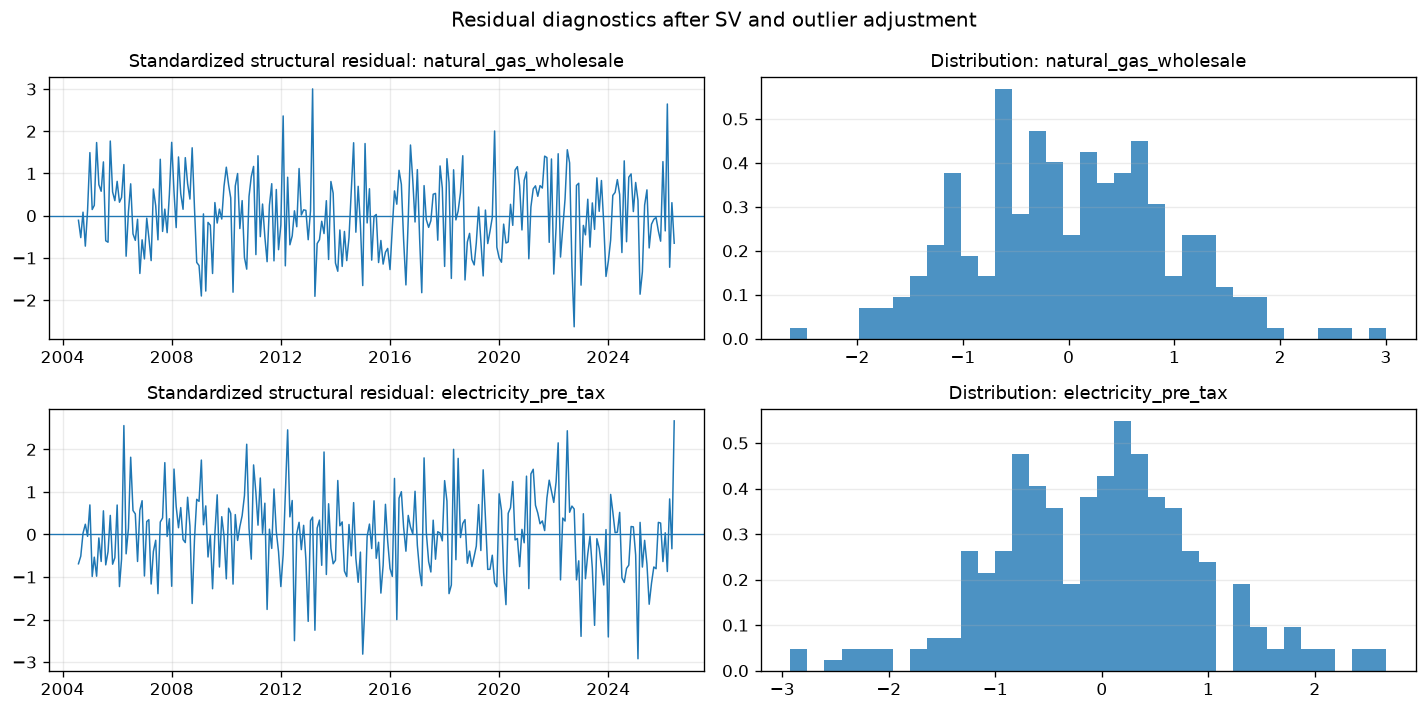

In [8]:
display(style_numeric_table(
    residual_diagnostic_table(result),
    caption="Standardized structural-residual diagnostics",
))
plot_standardized_residuals(result)
plt.show()

## 7. Ragged-edge nowcast and forecasts

Forecast origin: 2026-08-01
Forecast horizon used: 4 months


,month_02,month_03,month_04,month_05,month_06,month_07,month_08,month_09,month_10,month_11,month_12
2026-09-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2026-10-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
2026-11-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
2026-12-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-07-01,nowcast,—,0.24,0.24,0.24,0.24,0.25
2026-08-01,nowcast,—,0.23,0.24,0.24,0.24,0.25


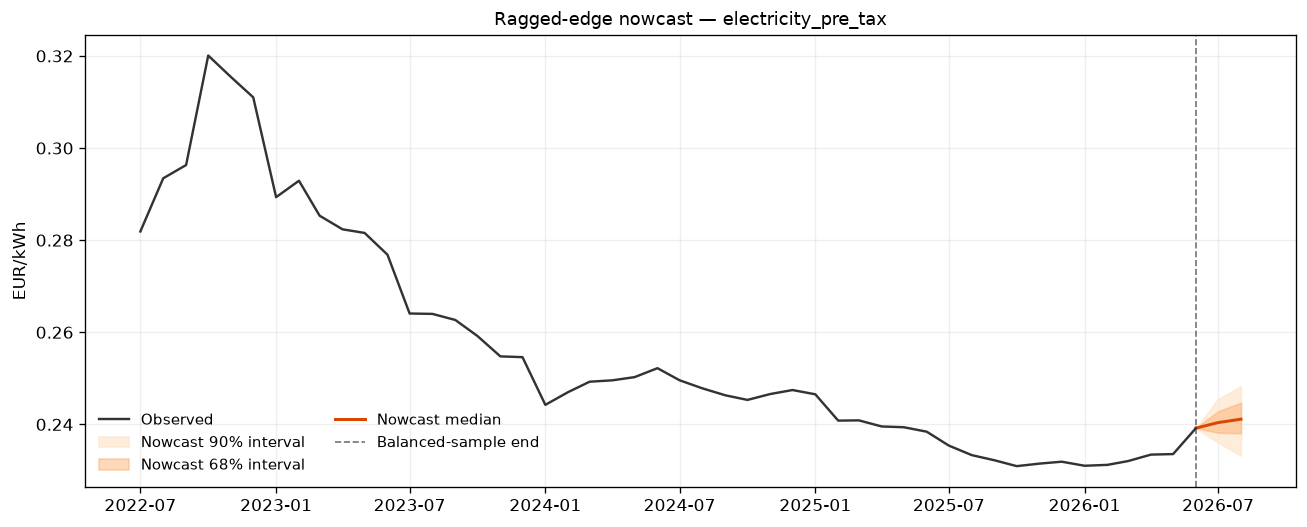

In [9]:
FORECAST_ORIGIN = prep["last_calendar_date"]
MONTHS_TO_YEAR_END = 12 - FORECAST_ORIGIN.month
if MONTHS_TO_YEAR_END == 0:
    MONTHS_TO_YEAR_END = 12
H = max(3, MONTHS_TO_YEAR_END)
FORECAST_DRAWS = min(1_000, result["n_draws"])

future_dates = pd.date_range(
    FORECAST_ORIGIN + pd.offsets.MonthBegin(1),
    periods=H,
    freq="MS",
)
future_seasonal_dummies = make_electricity_seasonal_dummies(
    future_dates,
    reference_month=REFERENCE_MONTH,
)

forecast_unconditional = forecast_bvar_sv_outlier(
    result,
    H=H,
    future_exog=future_seasonal_dummies,
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=True,
    seed=2026,
)

print(f"Forecast origin: {FORECAST_ORIGIN.date()}")
print(f"Forecast horizon used: {H} months")
display(style_numeric_table(
    forecast_unconditional["future_exog"],
    caption="Future seasonal dummies supplied to every posterior forecast draw",
))

nowcast_table = nowcast_summary_table(
    forecast_unconditional,
    observed_levels=levels,
    variable="electricity_pre_tax",
    missing_only=True,
)
if nowcast_table.empty:
    print("No missing electricity_pre_tax observation is present in the ragged edge.")
else:
    display(style_numeric_table(
        nowcast_table,
        caption="Ragged-edge nowcast — electricity_pre_tax",
    ))
plot_nowcast_fan(
    forecast_unconditional,
    historical_levels=levels,
    variable="electricity_pre_tax",
    ylabel=UNITS["electricity_pre_tax"],
)
plt.show()

,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,42.73,51.72,58.43,65.27,72.86
3 months,3.00,2026-11-01,32.01,47.30,60.25,75.07,93.58
End of 2026,4.00,2026-12-01,27.65,44.33,60.52,78.06,99.95


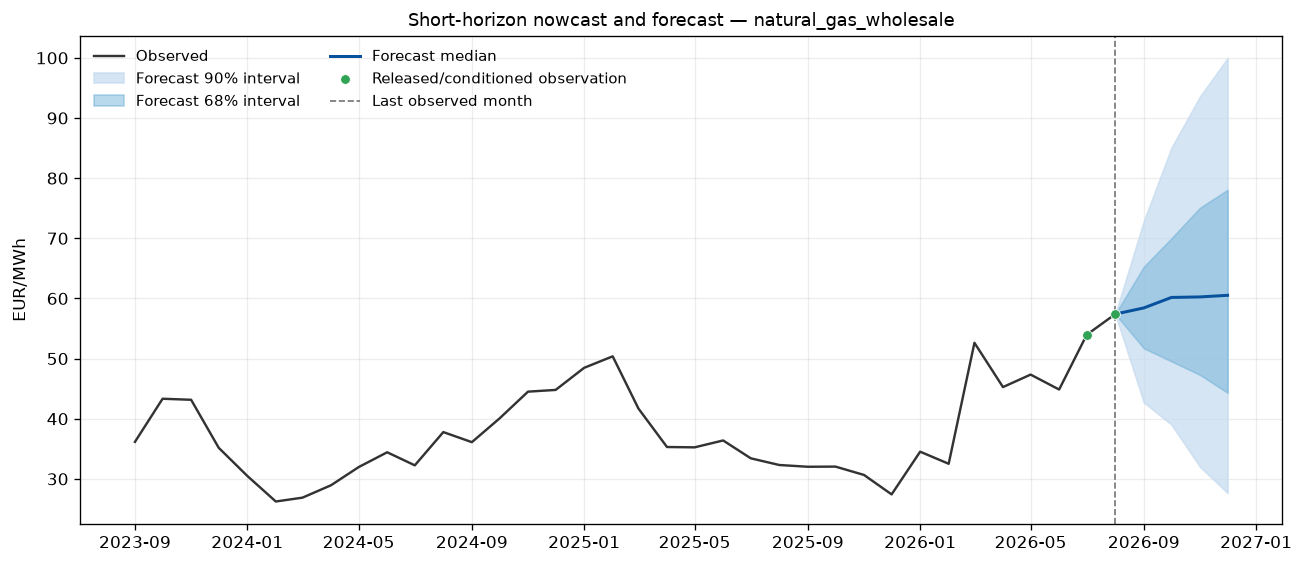

,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,0.23,0.24,0.24,0.25,0.25
3 months,3.00,2026-11-01,0.22,0.24,0.24,0.25,0.26
End of 2026,4.00,2026-12-01,0.22,0.24,0.24,0.25,0.26


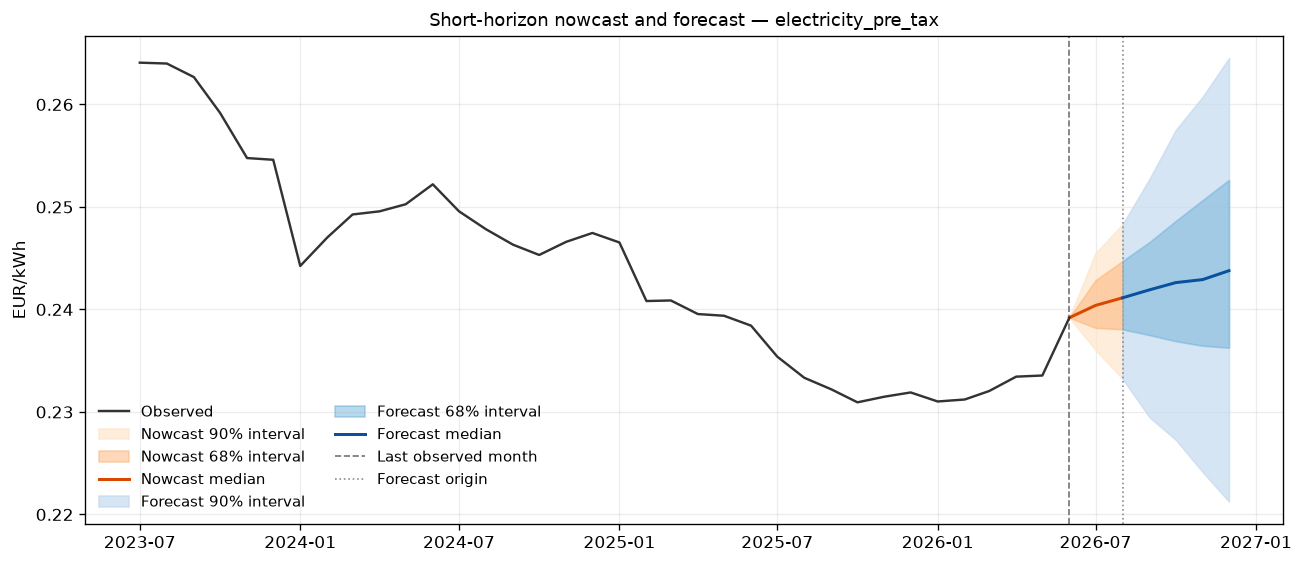

In [10]:
for variable in VARIABLES:
    table = forecast_horizon_table(forecast_unconditional, variable)
    display(style_numeric_table(
        table,
        caption=f"Unconditional level forecast — {variable} ({UNITS[variable]})",
    ))
    plot_short_forecast_fan(
        forecast_unconditional,
        historical_levels=levels,
        variable=variable,
        ylabel=UNITS[variable],
    )
    plt.show()

### 7.1 Conditional wholesale-gas scenario

The future wholesale natural-gas level is fixed at 10% above its latest observed value. Seasonal dummies remain fixed by the calendar and are identical in the unconditional and conditional runs.

Maximum absolute condition error: 2.42 × 10⁻¹³


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,0.23,0.24,0.24,0.25,0.25
3 months,3.00,2026-11-01,0.23,0.24,0.24,0.25,0.26
End of 2026,4.00,2026-12-01,0.23,0.24,0.24,0.25,0.26


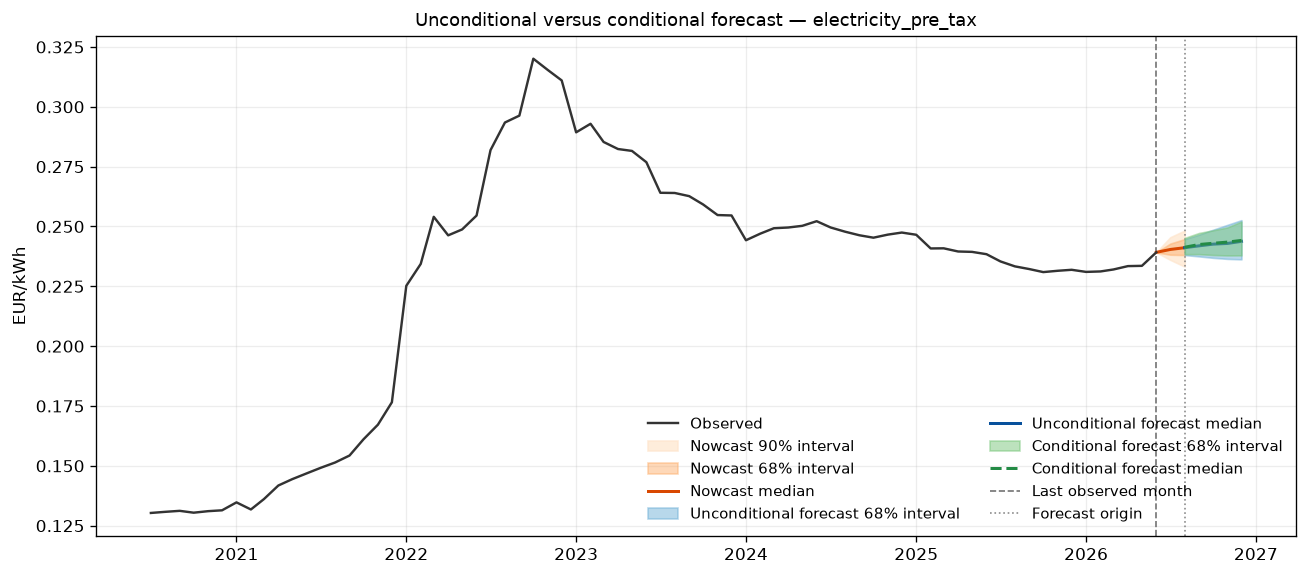

In [11]:
last_wholesale_level = levels["natural_gas_wholesale"].dropna().iloc[-1]
wholesale_up_10 = np.full(H, 1.10 * last_wholesale_level)

forecast_conditional = forecast_bvar_sv_outlier(
    result,
    H=H,
    level_conditions={"natural_gas_wholesale": wholesale_up_10},
    future_exog=future_seasonal_dummies,
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=True,
    seed=2026,
)

condition_error = np.max(np.abs(
    forecast_conditional["future_level_paths"][:, :, VARIABLES.index("natural_gas_wholesale")]
    - wholesale_up_10[None, :]
))
print(f"Maximum absolute condition error: {format_number(condition_error)}")

display(style_numeric_table(
    forecast_horizon_table(forecast_conditional, "electricity_pre_tax"),
    caption="Conditional electricity_pre_tax forecast (EUR/kWh)",
))
plot_forecast_comparison(
    forecast_unconditional,
    forecast_conditional,
    historical_levels=levels,
    variable="electricity_pre_tax",
    ylabel=UNITS["electricity_pre_tax"],
)
plt.show()

### 7.2 Tax re-attribution and HICP electricity forecast

,value
observations,276.00
maximum_absolute_error,2.84 × 10⁻¹⁴
tolerance,1.00 × 10⁻¹⁰


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,97.97,100.88,102.49,104.18,106.42
3 months,3.00,2026-11-01,96.03,100.50,102.85,105.67,109.33
End of 2026,4.00,2026-12-01,94.99,100.44,103.17,106.38,110.70


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,-1.00,1.94,3.56,5.28,7.54
3 months,3.00,2026-11-01,-2.71,1.83,4.21,7.06,10.77
End of 2026,4.00,2026-12-01,-3.91,1.60,4.37,7.62,11.99


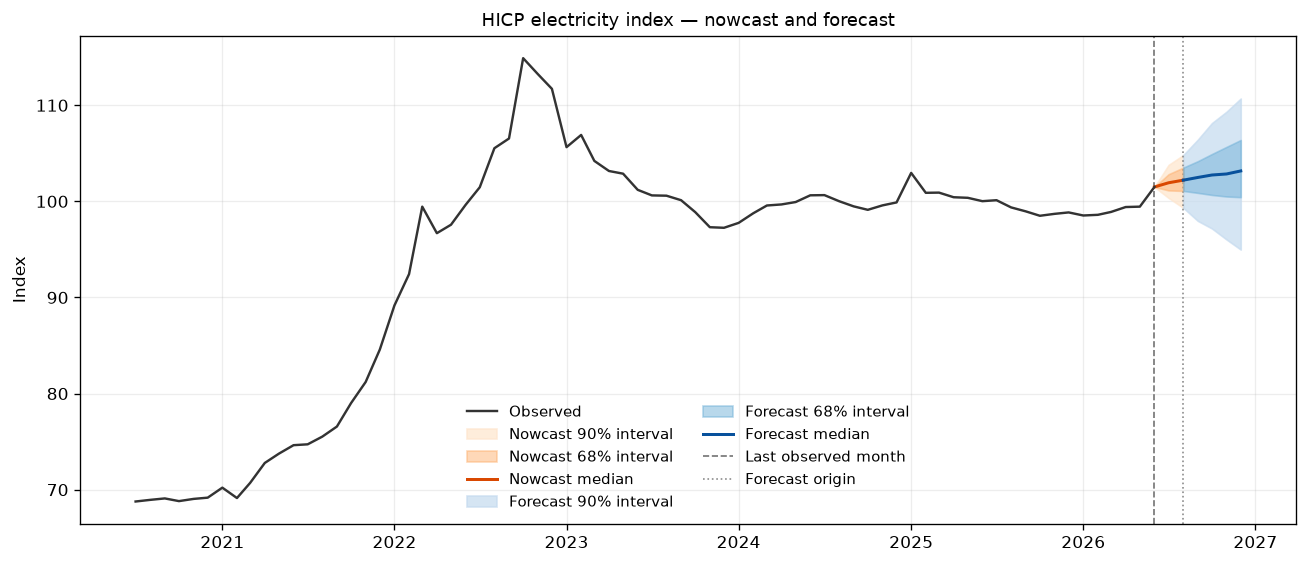

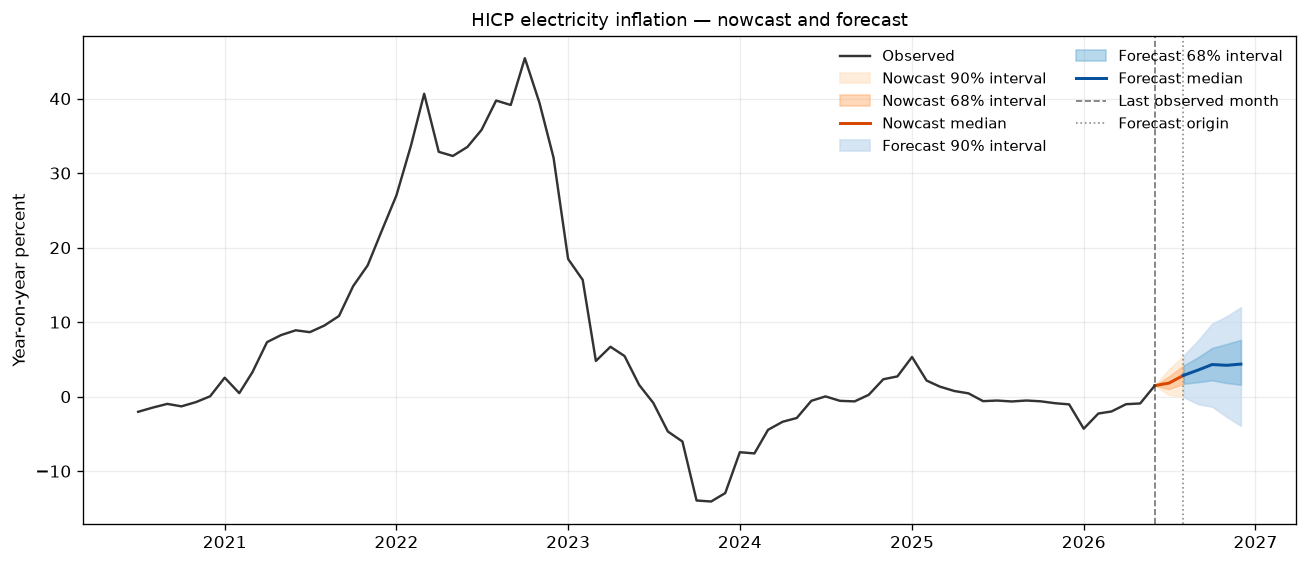

In [12]:
tax_context = None
try:
    tax_context = load_electricity_tax_context(ELECTRICITY_DATASET)
    display(style_numeric_table(
        validate_electricity_tax_round_trip(tax_context).to_frame("value"),
        caption="Electricity tax-construction round-trip check",
    ))

    hicp_unconditional = forecast_to_hicp_electricity(
        forecast_unconditional,
        result,
        tax_context,
    )
    hicp_conditional = forecast_to_hicp_electricity(
        forecast_conditional,
        result,
        tax_context,
    )

    display(style_numeric_table(
        path_horizon_table(
            hicp_unconditional["future_hicp_level_paths"],
            hicp_unconditional["future_dates"],
            forecast_unconditional["last_calendar_date"],
        ),
        caption="HICP electricity index forecast",
    ))
    display(style_numeric_table(
        path_horizon_table(
            hicp_unconditional["future_hicp_yoy_paths"],
            hicp_unconditional["future_dates"],
            forecast_unconditional["last_calendar_date"],
        ),
        caption="HICP electricity year-on-year inflation forecast (%)",
    ))

    plot_hicp_forecast_fan(
        hicp_unconditional,
        kind="level",
        component_label="electricity",
    )
    plot_hicp_forecast_fan(
        hicp_unconditional,
        kind="yoy",
        component_label="electricity",
    )
    plt.show()
except (FileNotFoundError, KeyError) as exc:
    print("Tax re-attribution skipped:")
    print(exc)

## 8. Structural analysis

The deterministic seasonal block belongs to the baseline path. It does not alter the companion roots or the impulse propagation matrices. In the historical decomposition, however, the estimated seasonal contribution is included in the reconstructed deterministic base so that the decomposition remains exactly additive.

Recursive identification
Reference date: 2026-06-01
HD maximum reconstruction error: 4.26 × 10⁻¹⁴


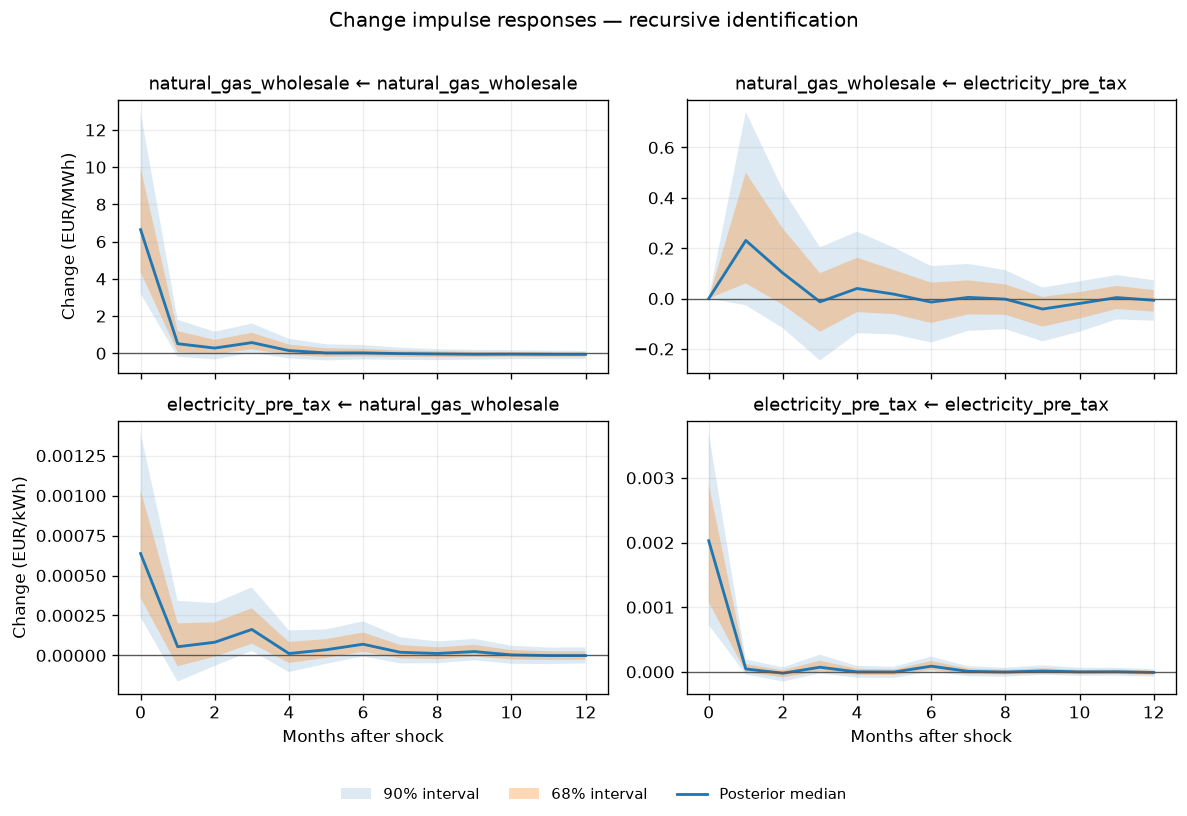

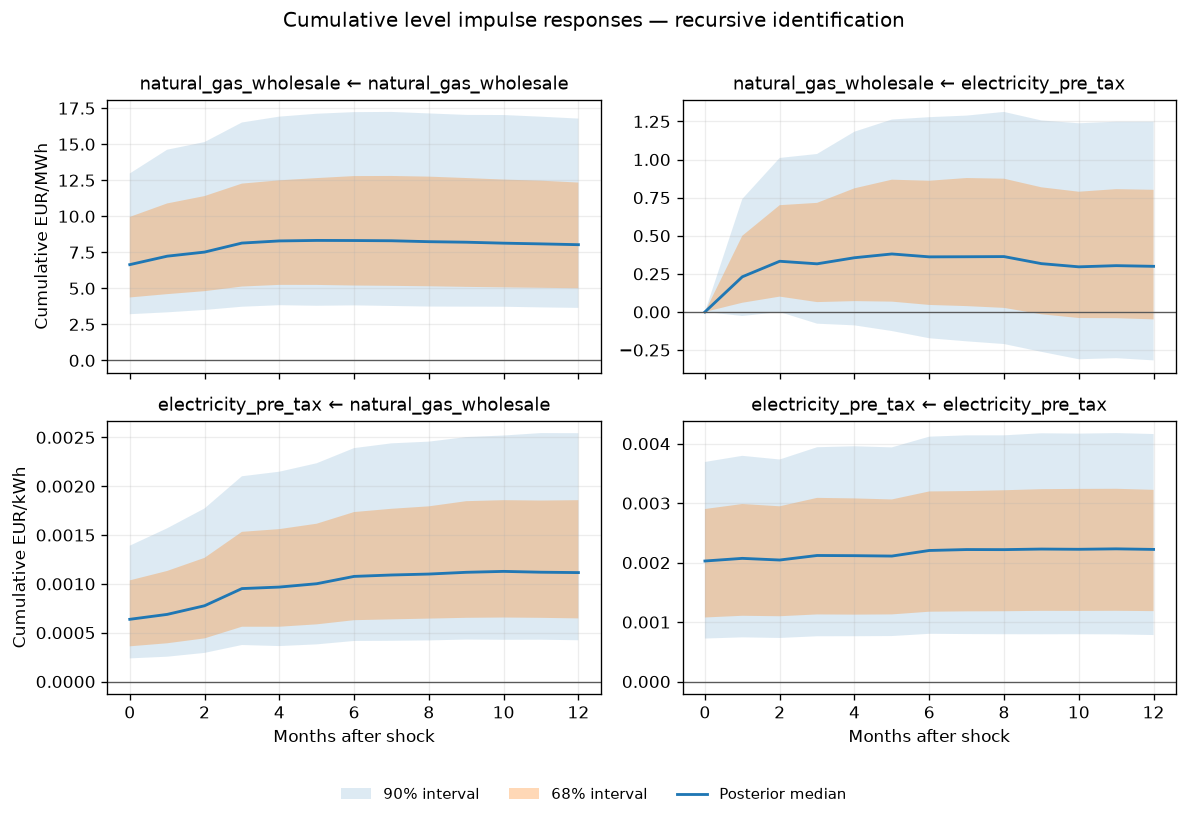

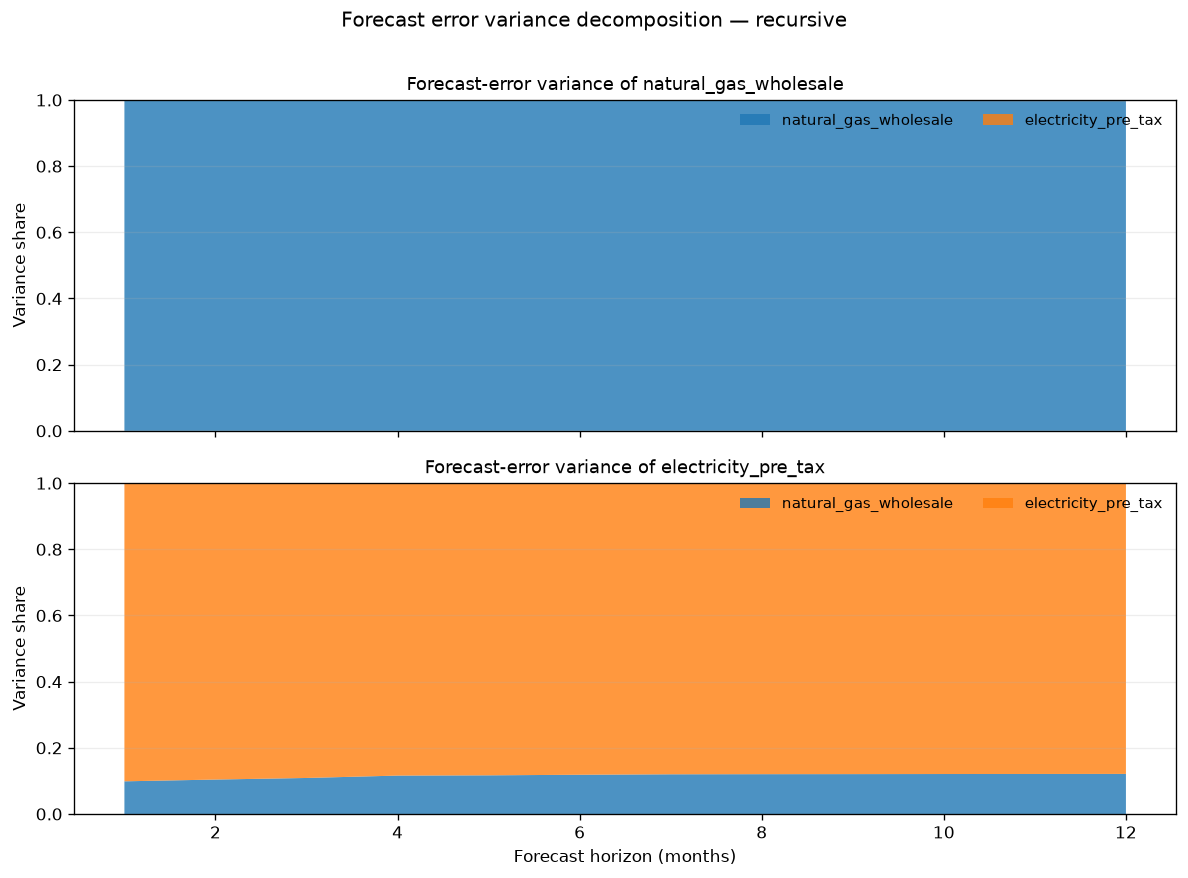

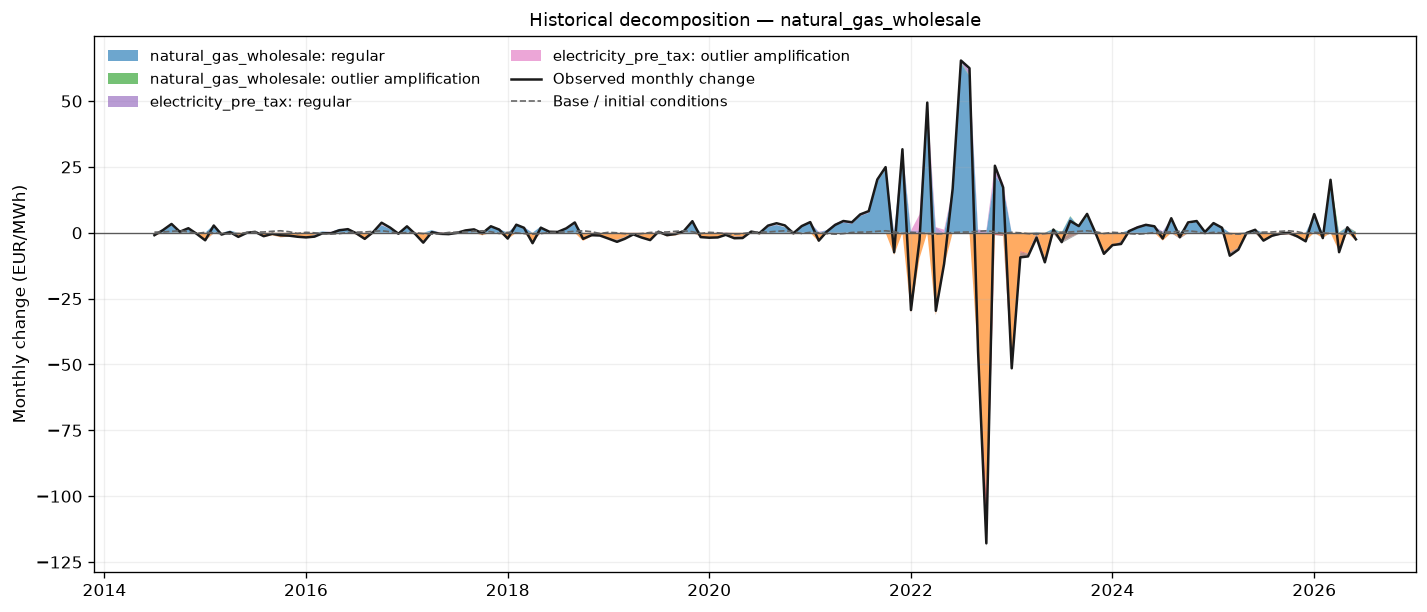

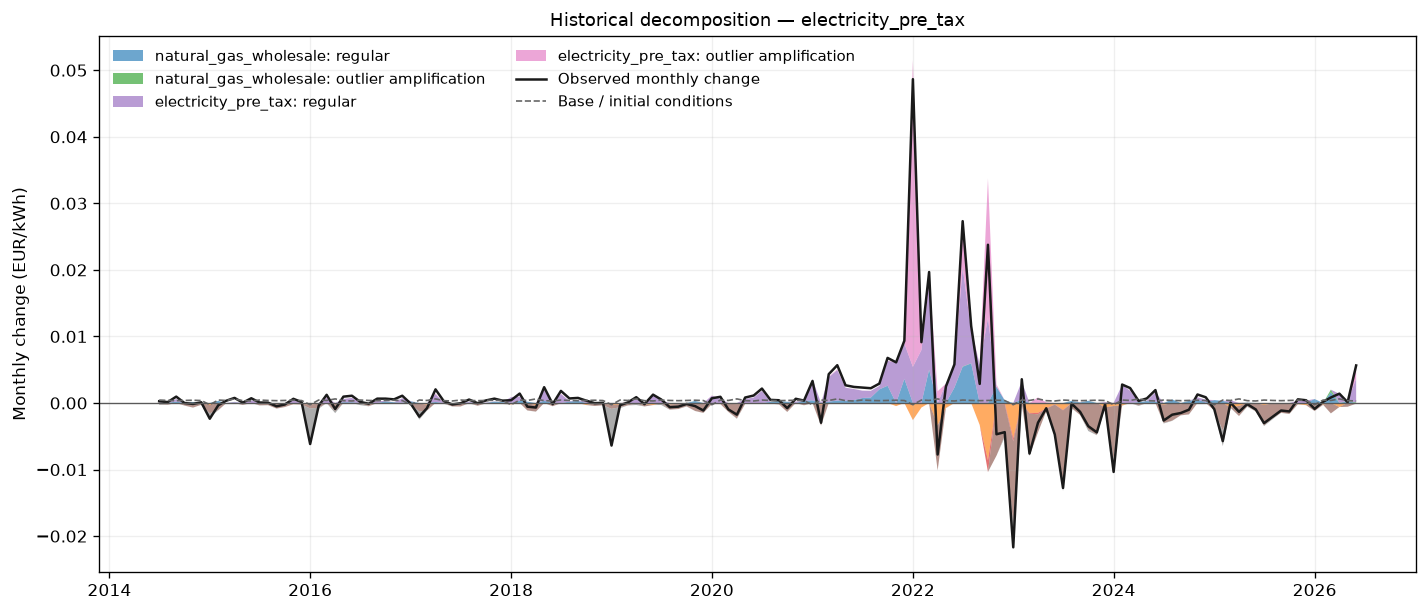


Sign-restricted identification
Accepted posterior-draw share: 100.00%
Mean attempts per accepted draw: 2.30
HD maximum reconstruction error: 2.36 × 10⁻¹²


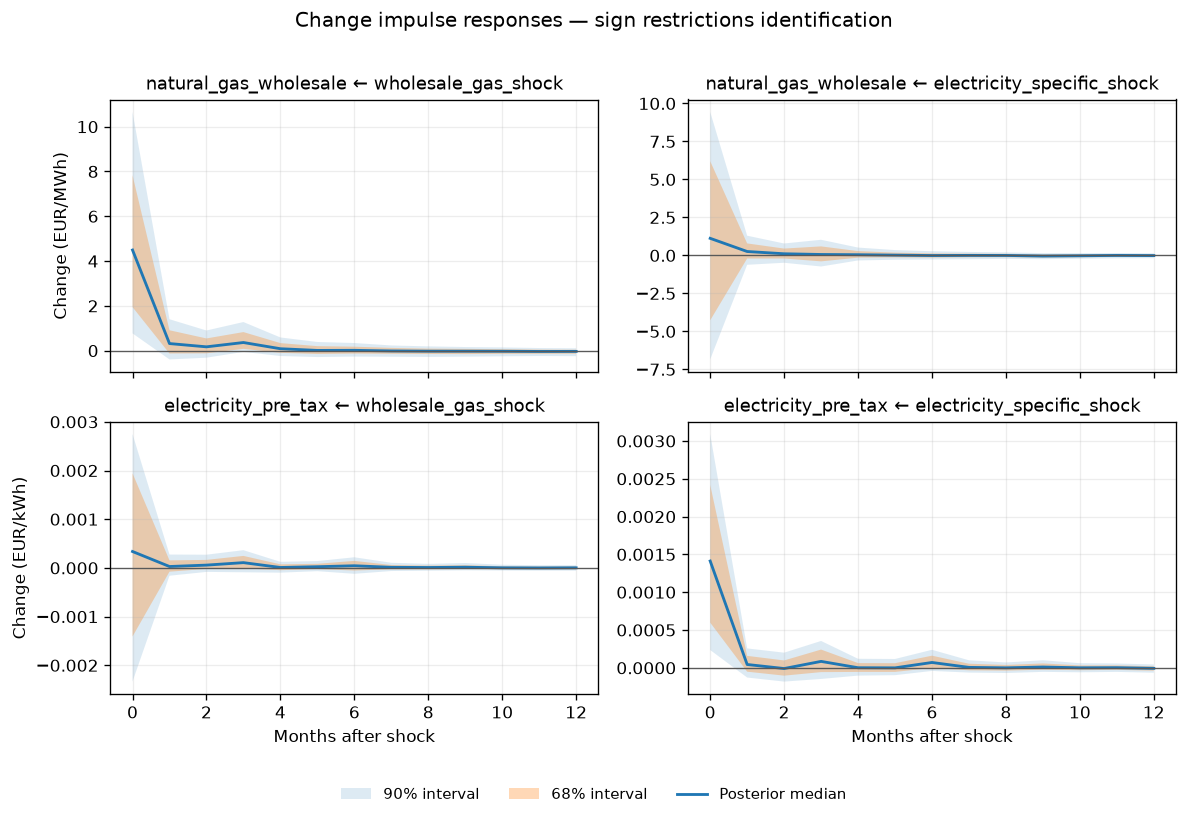

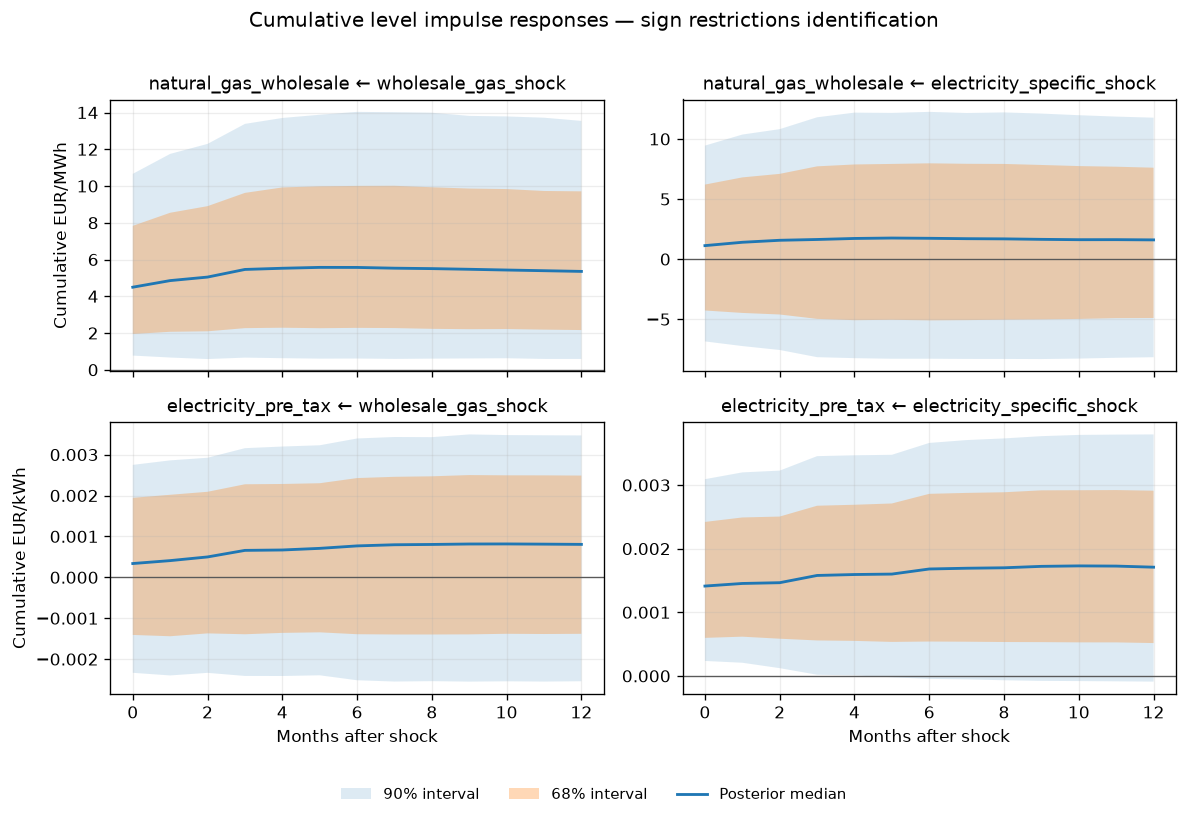

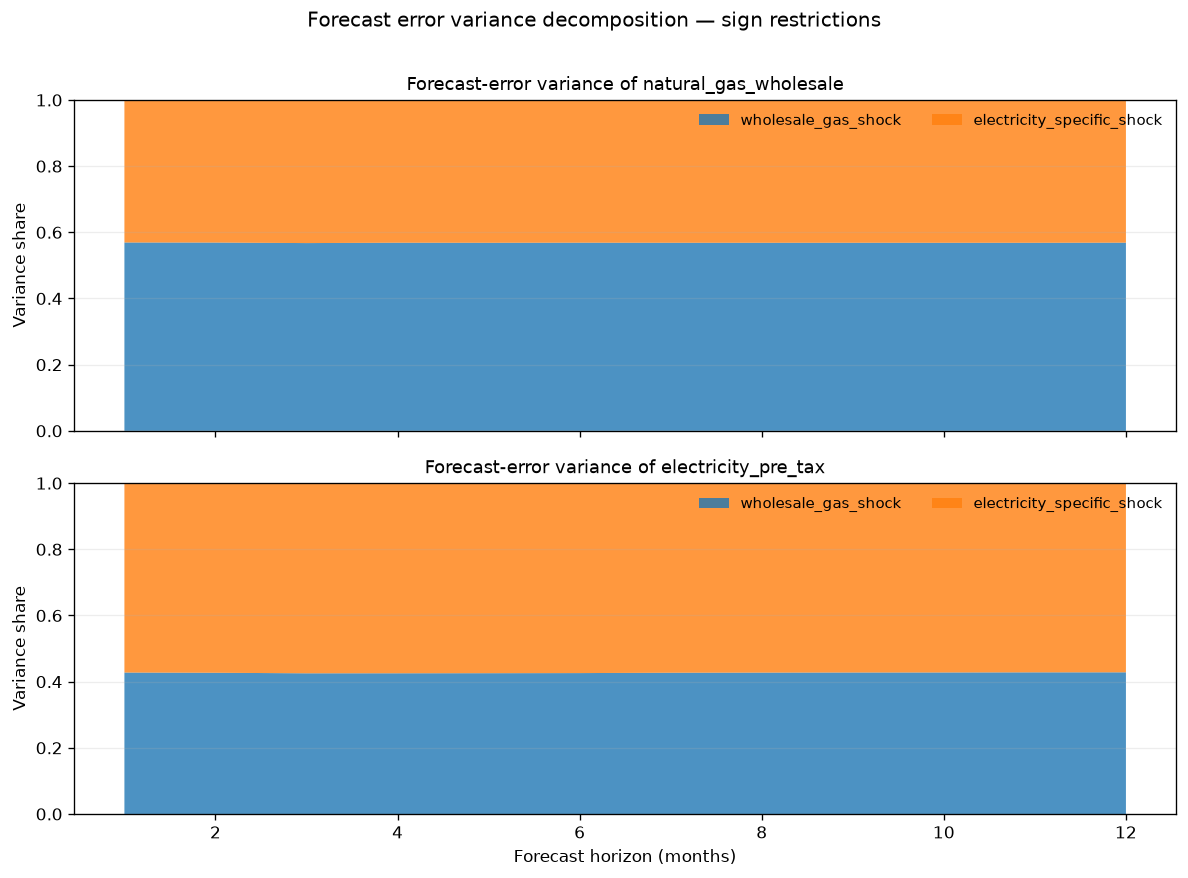

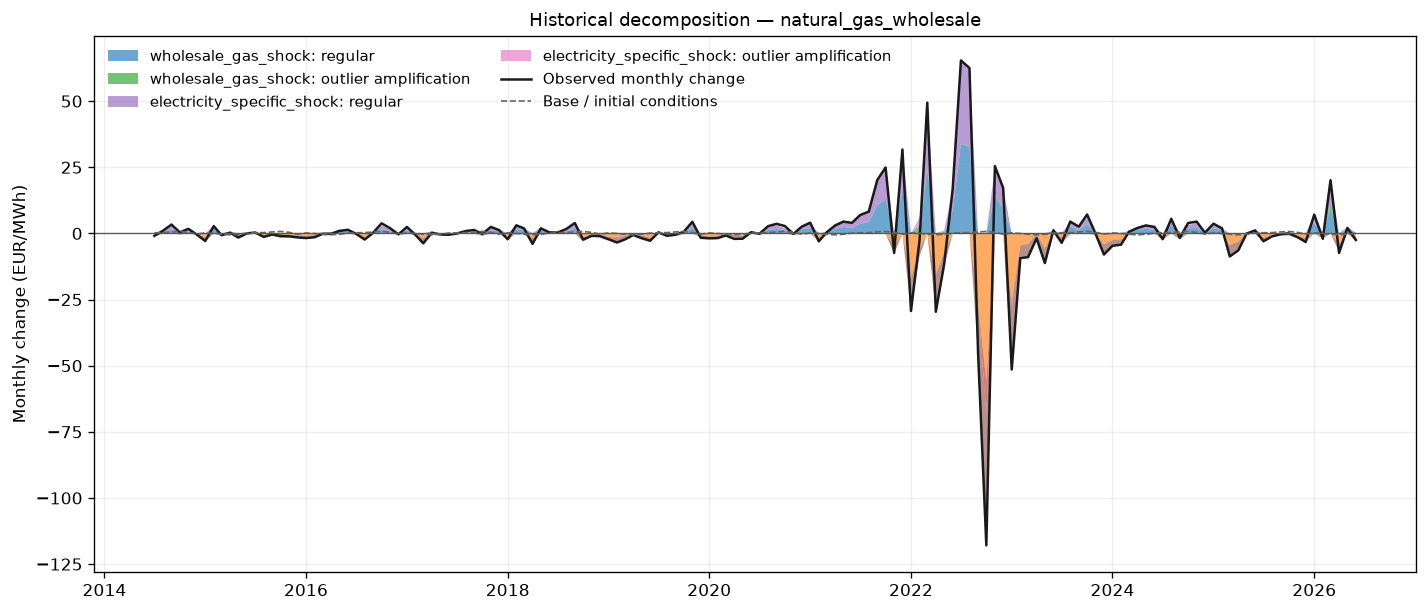

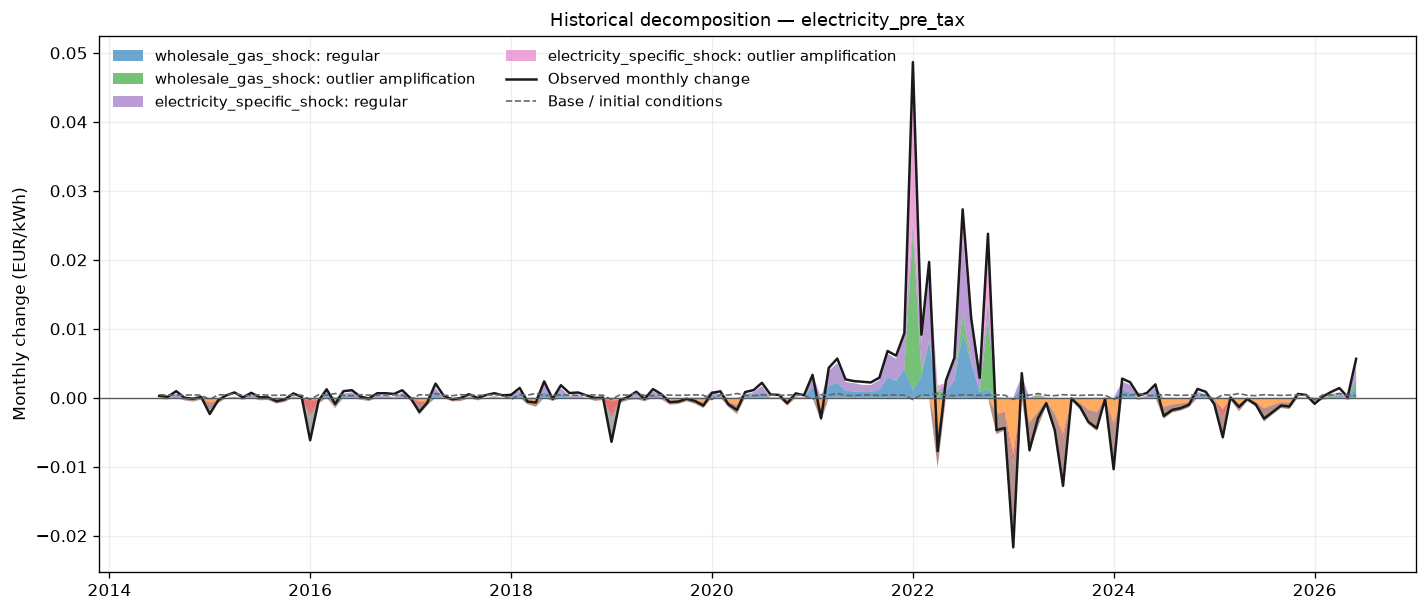

In [13]:
ELECTRICITY_SIGN_RESTRICTIONS = {
    "wholesale_gas_shock": {
        "natural_gas_wholesale": {0: +1},
    },
    "electricity_specific_shock": {
        "electricity_pre_tax": {0: +1},
    },
}

STRUCTURAL_REFERENCE_DATE = prep["balanced_end"]
STRUCTURAL_HORIZON = 12

irf_recursive = impulse_responses(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="structural_std",
    include_outlier_scale=False,
)
fevd_recursive = forecast_error_variance_decomposition(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
)
hd_recursive = historical_decomposition(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    split_outlier_amplification=True,
)

print("Recursive identification")
print(f"Reference date: {pd.Timestamp(STRUCTURAL_REFERENCE_DATE).date()}")
print(f"HD maximum reconstruction error: {format_number(hd_recursive['max_reconstruction_error'])}")
plot_impulse_responses(irf_recursive, cumulative=False, units=UNITS)
plot_impulse_responses(irf_recursive, cumulative=True, units=UNITS)
plot_fevd(fevd_recursive)
for response in VARIABLES:
    plot_historical_decomposition(
        hd_recursive,
        response=response,
        last_obs=144,
        unit=UNITS[response],
    )
plt.show()

irf_sign = impulse_responses(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=ELECTRICITY_SIGN_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="structural_std",
    include_outlier_scale=False,
    max_tries=10_000,
    seed=SEED,
)
fevd_sign = forecast_error_variance_decomposition(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=ELECTRICITY_SIGN_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
    max_tries=10_000,
    seed=SEED,
)
hd_sign = historical_decomposition(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=ELECTRICITY_SIGN_RESTRICTIONS,
    split_outlier_amplification=True,
    max_tries=10_000,
    seed=SEED,
)

print("\nSign-restricted identification")
print(f"Accepted posterior-draw share: {irf_sign['acceptance_rate']:.2%}")
print(f"Mean attempts per accepted draw: {irf_sign['mean_attempts_per_accepted_draw']:.2f}")
print(f"HD maximum reconstruction error: {format_number(hd_sign['max_reconstruction_error'])}")
plot_impulse_responses(irf_sign, cumulative=False, units=UNITS)
plot_impulse_responses(irf_sign, cumulative=True, units=UNITS)
plot_fevd(fevd_sign)
for response in VARIABLES:
    plot_historical_decomposition(
        hd_sign,
        response=response,
        last_obs=144,
        unit=UNITS[response],
    )
plt.show()

## 9. Diagnosis

### 9.1 Stationarity of transformed endogenous data

In [14]:
stationarity_table = stationarity_tests(prep["balanced"])
display(style_numeric_table(
    stationarity_table,
    caption="Stationarity diagnostics",
))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
natural_gas_wholesale,-4.71,8.17 × 10⁻⁵,15.00,0.04,0.10,25.00,259.00
electricity_pre_tax,-4.18,7.17 × 10⁻⁴,16.00,0.11,0.10,7.00,258.00


### 9.2 MCMC effective sample size and autocorrelation

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
phi[electricity_pre_tax],0.08,0.04,65.28,4.49 × 10⁻³,0.12
"A[electricity_pre_tax,natural_gas_wholesale]",-9.80 × 10⁻⁵,3.05 × 10⁻⁵,87.68,3.25 × 10⁻⁶,0.11
phi[natural_gas_wholesale],0.17,0.05,91.41,5.66 × 10⁻³,0.10
log likelihood,899.59,12.49,242.10,0.80,0.06
p_outlier[electricity_pre_tax],0.05,0.02,256.99,9.50 × 10⁻⁴,0.06
own L1[natural_gas_wholesale],0.07,0.07,477.64,3.28 × 10⁻³,0.05
own L1[electricity_pre_tax],0.03,0.03,634.33,1.20 × 10⁻³,0.04
p_outlier[natural_gas_wholesale],0.01,6.84 × 10⁻³,733.69,2.53 × 10⁻⁴,0.04
spectral radius,0.78,0.02,2589.13,4.23 × 10⁻⁴,0.02


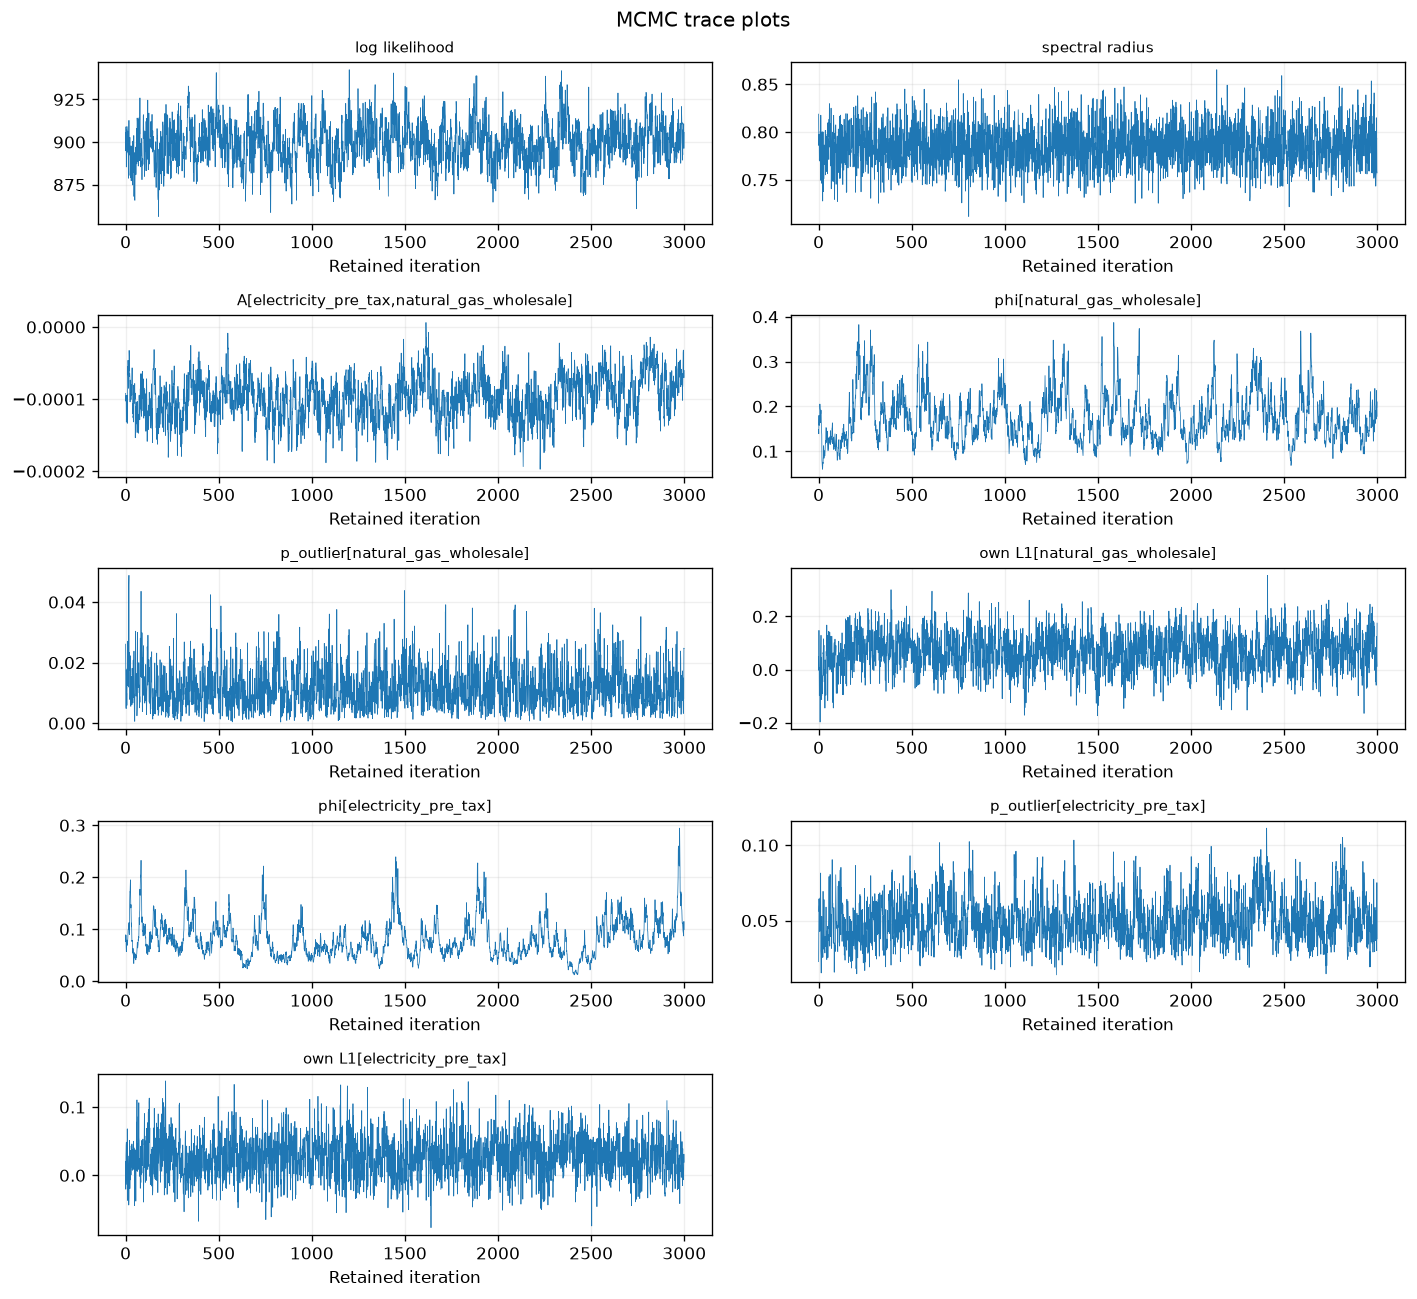

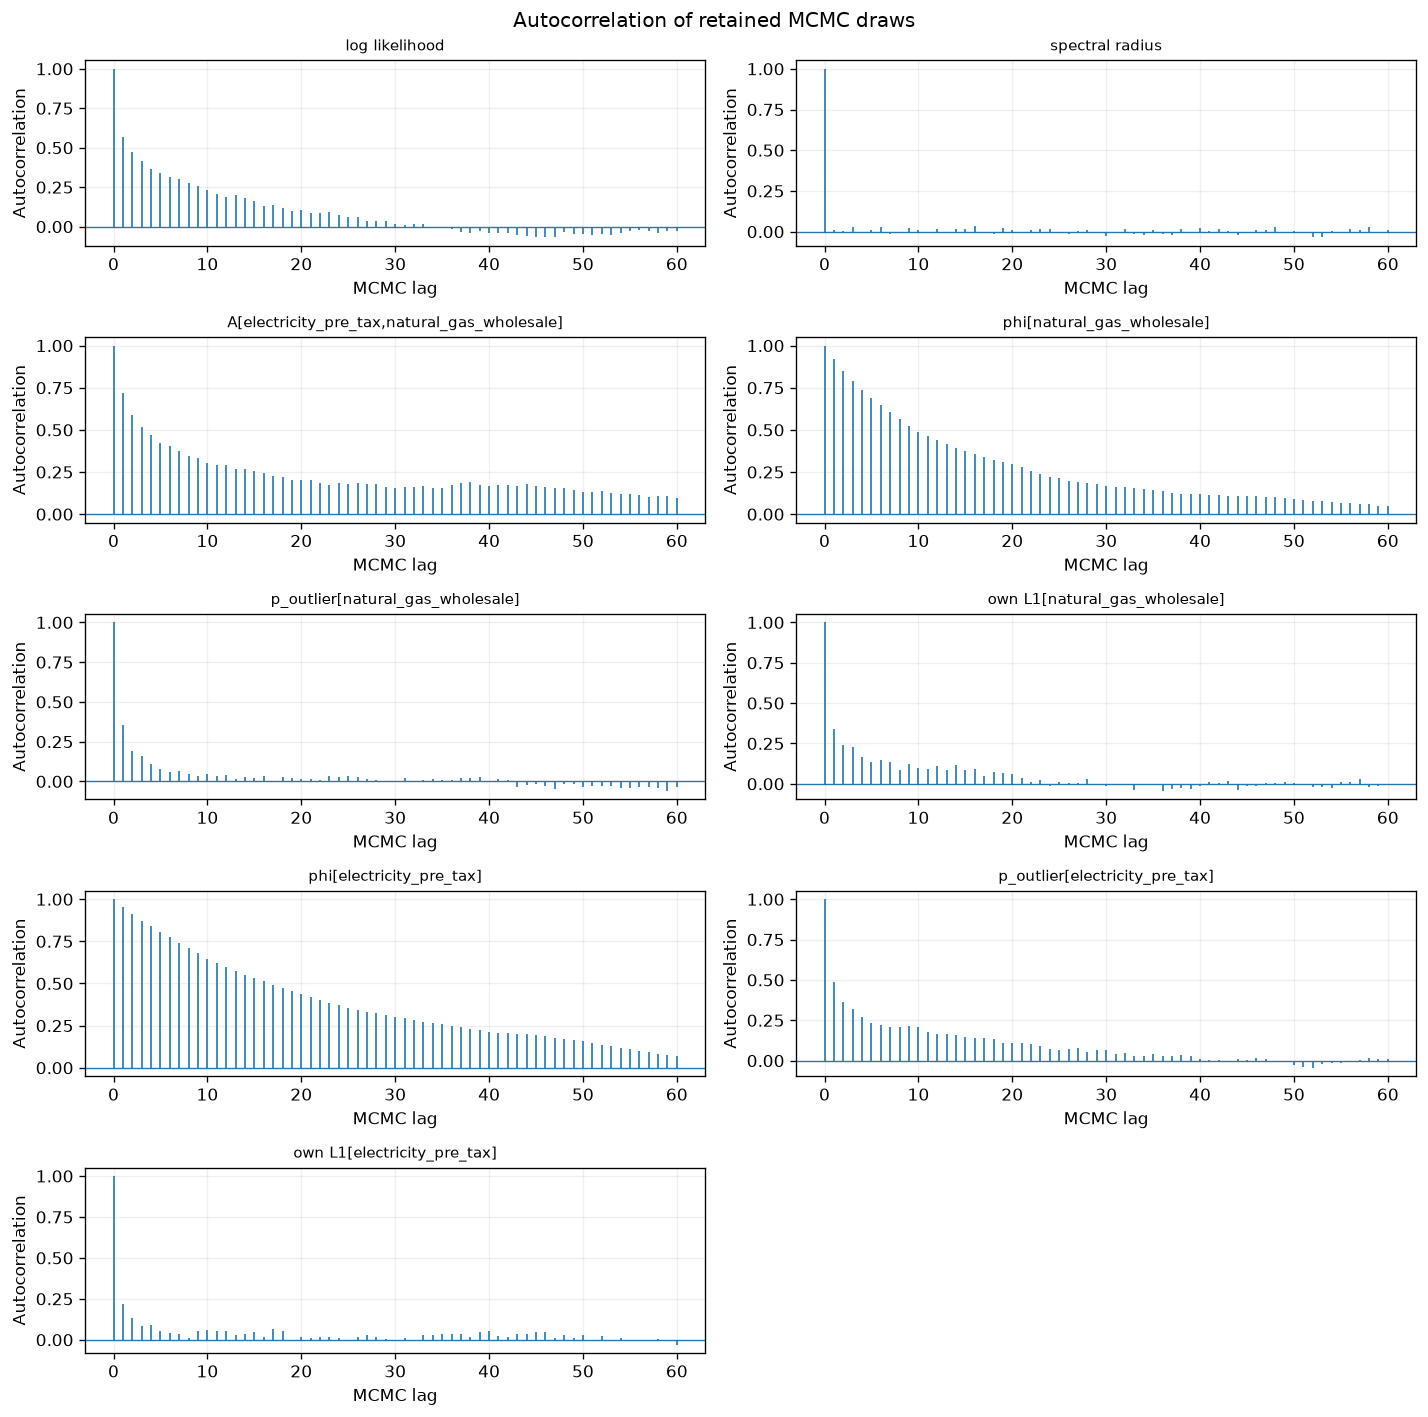

In [15]:
diagnostic_table = mcmc_diagnostics(result)
display(style_numeric_table(
    diagnostic_table.sort_values("ESS"),
    caption="MCMC diagnostics",
))
plot_trace_grid(result)
plot_chain_acf_grid(result, nlags=60)
plt.show()

### 9.3 Stability

,value
retained_draws,3000.00
median_spectral_radius,0.78
q95_spectral_radius,0.82
maximum_spectral_radius,0.87
retained_unstable_share,0.00
B_total_proposals,6000.00
B_unstable_proposals,0.00
B_instability_rejection_rate,0.00


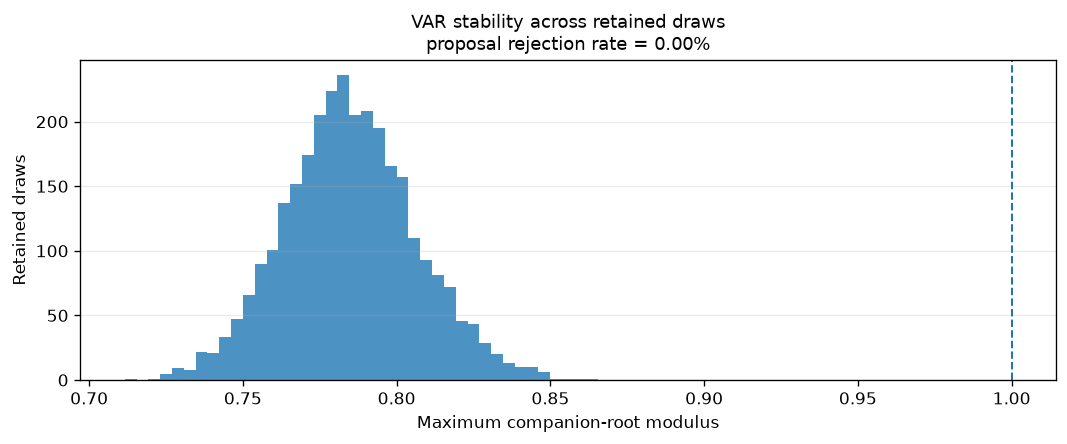

In [16]:
display(style_numeric_table(
    stability_diagnostics(result).to_frame("value"),
    caption="VAR stability diagnostics",
))
plot_spectral_radius(result)
plt.show()

### 9.4 Posterior predictive checks

,observed,replicated_median,replicated_q05,replicated_q95
natural_gas_wholesale: mean,0.13,0.10,-1.38,1.52
natural_gas_wholesale: sd,11.79,10.66,7.30,22.18
natural_gas_wholesale: maximum_absolute,117.89,91.13,49.89,333.75


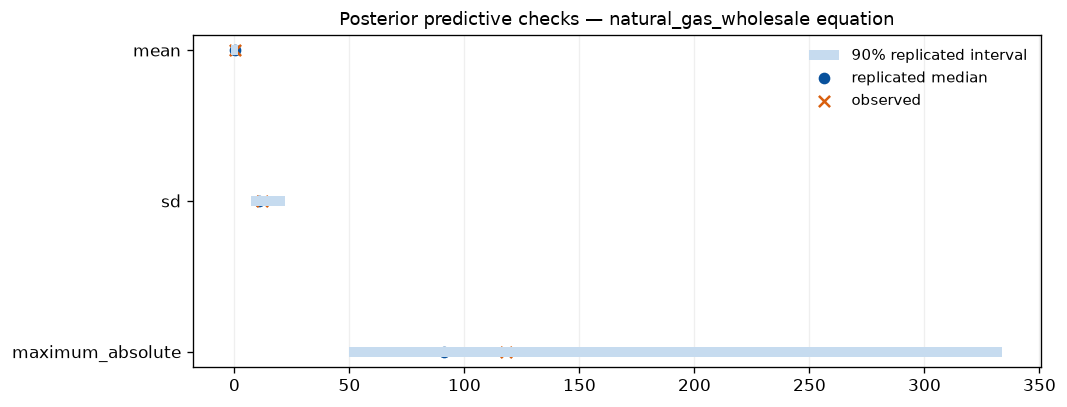

,observed,replicated_median,replicated_q05,replicated_q95
electricity_pre_tax: mean,5.29 × 10⁻⁴,3.32 × 10⁻⁴,-5.51 × 10⁻⁴,1.29 × 10⁻³
electricity_pre_tax: sd,4.75 × 10⁻³,6.00 × 10⁻³,3.32 × 10⁻³,0.01
electricity_pre_tax: maximum_absolute,0.05,0.07,0.02,0.19


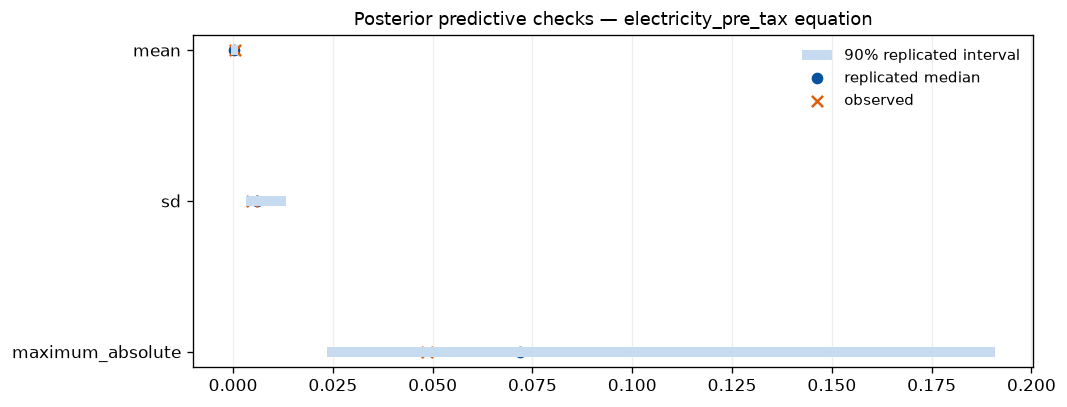

In [17]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=2027,
)
for equation in VARIABLES:
    equation_rows = ppc_summary.loc[
        [str(index).startswith(f"{equation}:") for index in ppc_summary.index]
    ]
    display(style_numeric_table(
        equation_rows,
        caption=f"Posterior predictive checks — {equation}",
    ))
    plot_posterior_predictive_check(ppc_summary, equation=equation)
    plt.show()

## 10. Validation checklist

Before freezing the electricity model, verify:

- the seasonal design has exactly eleven columns and no collinearity with the constant;
- the gas model remains numerically identical when `exog=None`;
- all future forecasts receive the same calendar-dummy convention as estimation;
- the historical decomposition reconstructs the observed changes within numerical precision;
- the Run ID and saved result directory are retained in the canonical HTML export.